# Data Processing for Kongbserg - Tampere Dataset

-   https://www.sciencedirect.com/science/article/pii/S1350630724007684

Use `TUNI_parallel.py` to process data. This file is for visualizations and validation.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from signal_analysis import FFT_TSA, order_track_FFT, signal_TSA
# from signal_analysis import FFT_TSA, order_track_FFT, order_track_signal, signal_TSA
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
import mdfreader

from scipy.interpolate import CubicSpline
from scipy.stats import kurtosis, skew

In [2]:
data_folder = Path("/Volumes/T7-Aalto/TUNI-KONG_comb")
processed_data_folder = Path.cwd().parent.parent / "data"

sampling_rate = 5000  # Hz
GMF = 225  # Gear Mesh Frequency in Hz (for 1500 RPM)
pinion_teeth = 9


def _load_mf4(file_path):
    mdf_data = mdfreader.Mdf(file_path)
    channel_list = list(mdf_data.keys())
    channel_data = mdf_data[channel_list[0]]["data"]
    return channel_data


def fold(x, w):
    extra = len(x) % w
    if extra != 0:
        x = x[:-extra]
    return x.reshape(-1, w)

/var/folders/cx/1v2hhggj48s5vpt1wv2m167h0000gp/T/ipykernel_39677/1556892136.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


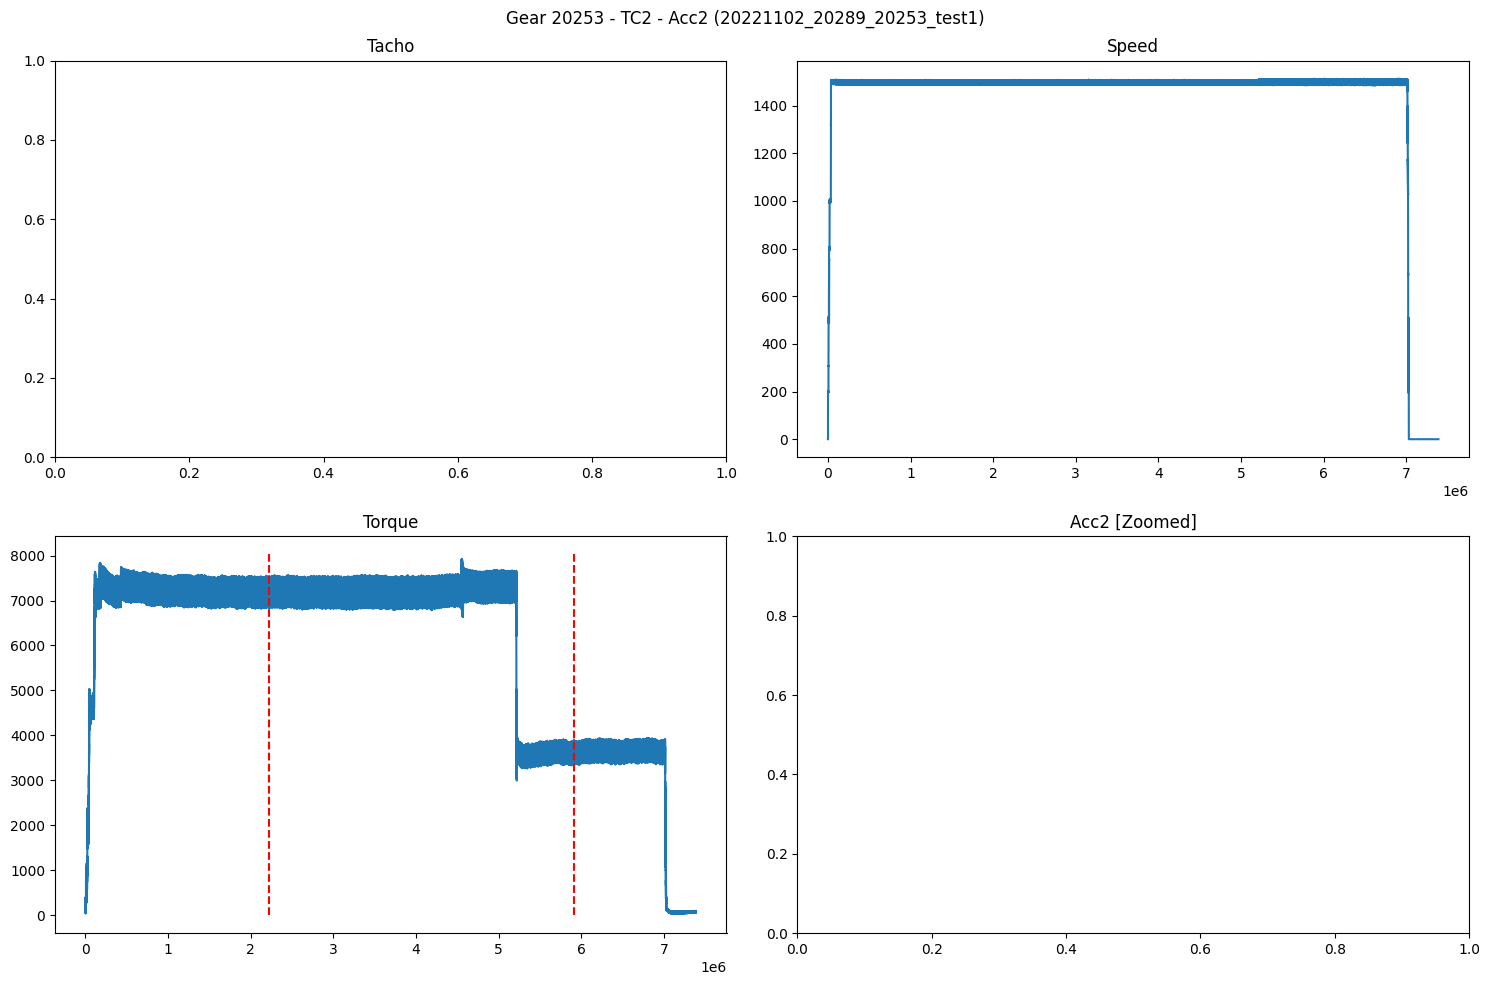

In [4]:
run = "20221102_20289_20253_test1"
TC = 2
sensor = 2
gear = run.split("_")[TC]

file_path = data_folder / run / f"TC{TC}_accelerometer_{sensor}_{gear}.mf4"

signal = _load_mf4(file_path)
signal = signal[len(signal) // 2 : len(signal) // 2 + 10000]
tacho = _load_mf4(file_path.parent / "Encoder.mf4")
speed = _load_mf4(file_path.parent / "rotational_speed.mf4")[::10]
torque = _load_mf4(file_path.parent / f"TC{TC}_torque_Pinion_{gear}.mf4")[::10]

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# axs[0, 0].plot(tacho, label="Tacho")
axs[0, 0].set_title("Tacho")
axs[0, 1].plot(speed, label="Speed")
axs[0, 1].set_title("Speed")
axs[1, 0].plot(torque, label="Torque")
axs[1, 0].set_title("Torque")
axs[1, 0].vlines(
    x=[0.3 * len(torque), 0.8 * len(torque)],
    ymin=0,
    ymax=max(torque) + 100,
    color="r",
    linestyle="--",
)
# axs[1, 1].plot(
#     signal[:5000],  # Plot only the first 5000 samples for clarity
#     label="Signal (1s / 5000 samples)",
# )
axs[1, 1].set_title(f"Acc{sensor} [Zoomed]")

fig.suptitle(f"Gear {gear} - TC{TC} - Acc{sensor} ({run})")
fig.set_tight_layout(True)
fig.show()

/var/folders/cx/1v2hhggj48s5vpt1wv2m167h0000gp/T/ipykernel_39677/1290633817.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


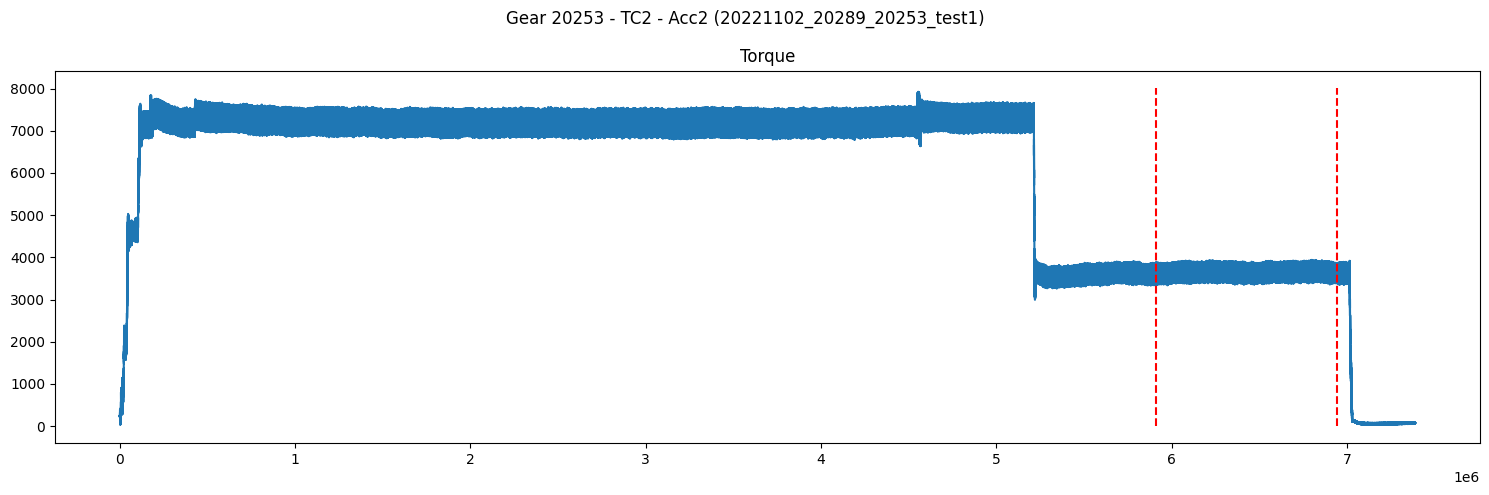

In [7]:
fig, axs = plt.subplots(figsize=(15, 5))

axs.plot(torque, label="Torque")
axs.set_title("Torque")
axs.vlines(
    x=[0.8 * len(torque), 0.94 * len(torque)],
    ymin=0,
    ymax=max(torque) + 100,
    color="r",
    linestyle="--",
)

fig.suptitle(f"Gear {gear} - TC{TC} - Acc{sensor} ({run})")
fig.set_tight_layout(True)
fig.show()

In [ ]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=np.fft.rfftfreq(len(signal), 1 / 5000),
        y=np.abs(np.fft.rfft(signal)),
        mode="lines",
        name="FFT Signal",
    )
)
for i in range(1, 9):
    fig.add_vline(
        x=i * GMF,
        line=dict(color="red", width=1, dash="dash"),
        annotation_text=f"{i} x GMF",
        annotation_position="top left",
    )
fig.update_layout(title=f"FFT of Signal - Gear {gear} - TC{TC} - Acc{sensor} ({run})")
fig.show()

In [ ]:
pro_data = pd.read_feather(processed_data_folder / f"TUNI_OT_{gear}.feather")
pro_data.groupby("run").count()

,gear,position,num_consequtive,class,class_opposite,sample_index,acc1,acc2
run,,,,,,,,
20221116_20290_20253_test1,17080,17080,17080,17080,17080,17080,17080,17080
20221118_20290_20253_test2,26408,26408,26408,26408,26408,26408,26408,26408
20221121_20290_20253_test3,26657,26657,26657,26657,26657,26657,26657,26657


In [ ]:
pro_data = pro_data[pro_data["run"] == run]
pro_data.head(3)

,gear,position,run,num_consequtive,class,class_opposite,sample_index,acc1,acc2
0,20290,1,20221121_20290_20253_test3,4,faulty,maybe_faulty,0,"[0.00034265104, 0.0001627406, 0.00081119436, 0...","[5.609403e-05, 0.00018634148, 0.00058136124, 0..."
1,20290,1,20221121_20290_20253_test3,4,faulty,maybe_faulty,1,"[1.4199198e-06, 0.00014512023, 0.00088052684, ...","[0.00012171407, 5.9965103e-05, 0.00063847704, ..."
2,20290,1,20221121_20290_20253_test3,4,faulty,maybe_faulty,2,"[0.00013995846, 0.00014316571, 0.0009868945, 0...","[0.00014905786, 0.00017820126, 0.00038740446, ..."


In [ ]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        y=pro_data[f"acc{sensor}"].iloc[10000], mode="lines", name=f"Acc{sensor}"
    )
)
fig.add_trace(
    go.Scatter(
        y=pro_data[f"acc{sensor}"].iloc[10000],
        mode="markers",
        marker=dict(color="blue", size=4),
    )
)
fig.update_layout(
    title=f"FFT OT - Gear {gear} - TC{TC} - Acc{sensor} ({run})",
    xaxis_title="Order",
    yaxis_title="Amplitude",
)
for i in range(1, 9):
    fig.add_vline(
        x=i * pinion_teeth,
        line=dict(color="red", width=1, dash="dash"),
        annotation_text=f"{i} x GMF",
        annotation_position="top left",
    )
fig.show()

In [ ]:
pro_data

,gear,position,run,num_consequtive,class,class_opposite,sample_index,acc1,acc2
0,20290,1,20221121_20290_20253_test3,4,faulty,maybe_faulty,0,"[0.00034265104, 0.0001627406, 0.00081119436, 0...","[5.609403e-05, 0.00018634148, 0.00058136124, 0..."
1,20290,1,20221121_20290_20253_test3,4,faulty,maybe_faulty,1,"[1.4199198e-06, 0.00014512023, 0.00088052684, ...","[0.00012171407, 5.9965103e-05, 0.00063847704, ..."
2,20290,1,20221121_20290_20253_test3,4,faulty,maybe_faulty,2,"[0.00013995846, 0.00014316571, 0.0009868945, 0...","[0.00014905786, 0.00017820126, 0.00038740446, ..."
3,20290,1,20221121_20290_20253_test3,4,faulty,maybe_faulty,3,"[0.00010200394, 0.00014720164, 0.00095338066, ...","[0.00017053178, 5.013005e-05, 0.0006062476, 0...."
4,20290,1,20221121_20290_20253_test3,4,faulty,maybe_faulty,4,"[3.0950022e-07, 0.00015744653, 0.00088200485, ...","[9.7292905e-05, 0.00017457166, 0.0005562285, 0..."
...,...,...,...,...,...,...,...,...,...
26652,20290,1,20221121_20290_20253_test3,4,faulty,maybe_faulty,26652,"[0.000109099856, 0.00022011262, 0.0010475076, ...","[0.00029518228, 7.683142e-05, 0.00080490747, 0..."
26653,20290,1,20221121_20290_20253_test3,4,faulty,maybe_faulty,26653,"[0.00020064617, 0.00021353994, 0.0009241819, 0...","[0.00018743059, 5.4765784e-05, 0.0007501706, 0..."
26654,20290,1,20221121_20290_20253_test3,4,faulty,maybe_faulty,26654,"[0.000301609, 0.00022178955, 0.00095293595, 0....","[6.8405375e-06, 0.0001446211, 0.0006798627, 0...."
26655,20290,1,20221121_20290_20253_test3,4,faulty,maybe_faulty,26655,"[0.00016037183, 0.0002099714, 0.00094333367, 0...","[6.937117e-05, 6.135847e-05, 0.0007969502, 0.0..."


In [ ]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        y=pro_data[f"acc{sensor}"].iloc[1000] - pro_data[f"acc{sensor}"].iloc[100],
        mode="lines",
        name=f"start - start",
    )
)
fig.add_trace(
    go.Scatter(
        y=pro_data[f"acc{sensor}"].iloc[8000] - pro_data[f"acc{sensor}"].iloc[100],
        mode="lines",
        name=f"mid - start",
    )
)
fig.add_trace(
    go.Scatter(
        y=pro_data[f"acc{sensor}"].iloc[17000] - pro_data[f"acc{sensor}"].iloc[100],
        mode="lines",
        name=f"end - mid",
    )
)
fig.update_layout(
    title=f"FFT OT - Gear {gear} - TC{TC} - Acc{sensor} ({run})",
    xaxis_title="Order",
    yaxis_title="Diff",
)
for i in range(1, 9):
    fig.add_vline(
        x=i * pinion_teeth,
        line=dict(color="red", width=1, dash="dash"),
        annotation_text=f"{i} x GMF",
        annotation_position="top left",
    )
fig.show()

In [ ]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        y=pro_data[f"acc{sensor}"].iloc[3000] - pro_data[f"acc{sensor}"].iloc[2500],
        mode="lines",
        name=f"Early",
    )
)
fig.add_trace(
    go.Scatter(
        y=pro_data[f"acc{sensor}"].iloc[12000] - pro_data[f"acc{sensor}"].iloc[11500],
        mode="lines",
        name=f"Mid",
    )
)
fig.add_trace(
    go.Scatter(
        y=pro_data[f"acc{sensor}"].iloc[17000] - pro_data[f"acc{sensor}"].iloc[16500],
        mode="lines",
        name=f"Late",
    )
)
fig.update_layout(
    title=f"FFT OT - Gear {gear} - TC{TC} - Acc{sensor} ({run})",
    xaxis_title="Order",
    yaxis_title="Diff",
)
for i in range(1, 9):
    fig.add_vline(
        x=i * pinion_teeth,
        line=dict(color="red", width=1, dash="dash"),
        annotation_text=f"{i} x GMF",
        annotation_position="top left",
    )
fig.show()

In [ ]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        y=np.array(pro_data[f"acc{sensor}"].iloc[16000:17000].to_list()).mean(axis=0),
        error_y=dict(
            type="data",
            array=np.std(
                np.array(pro_data[f"acc{sensor}"].iloc[16000:17000].to_list()), axis=0
            ),
            visible=True,
            color="black",
            thickness=1.5,
        ),
    )
)

In [ ]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        y=np.array(pro_data[f"acc{sensor}"].iloc[9000:10000].to_list()).mean(axis=0),
        error_y=dict(
            type="data",
            array=np.std(
                np.array(pro_data[f"acc{sensor}"].iloc[9000:10000].to_list()), axis=0
            ),
            visible=True,
            color="black",
            thickness=1.5,
        ),
        # mode="lines",
        # name=f"Acc{sensor} (16000-17000)",
    )
)
# np.std(np.array(pro_data[f"acc{sensor}"].iloc[16000:17000].to_list())[18])

In [ ]:
px.line(
    np.array(pro_data[f"acc{sensor}"].to_list())[:, 4],
).show()

## Trad comparison


In [ ]:
def RMS(x):
    """Calculate the Root Mean Square of a signal."""
    return np.sqrt(np.mean(np.square(x), axis=-1))

In [22]:
run = "20221121_20290_20253_test3"
TC = 1
sensor = 1
gear = run.split("_")[TC]
file_path = data_folder / run / f"TC{TC}_accelerometer_{sensor}_{gear}.mf4"

measurement_len = 99 * 200
window_len = 50

signal = _load_mf4(file_path)

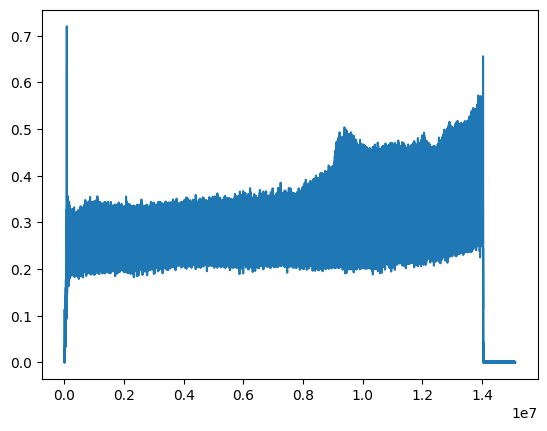

In [23]:
plt.plot(RMS(fold(signal, window_len)))
# plt.vlines(
#     x=[int(0.3 * 75549), int(0.7 * 75549)], ymin=0, ymax=1, color="r", linestyle="--"
# )

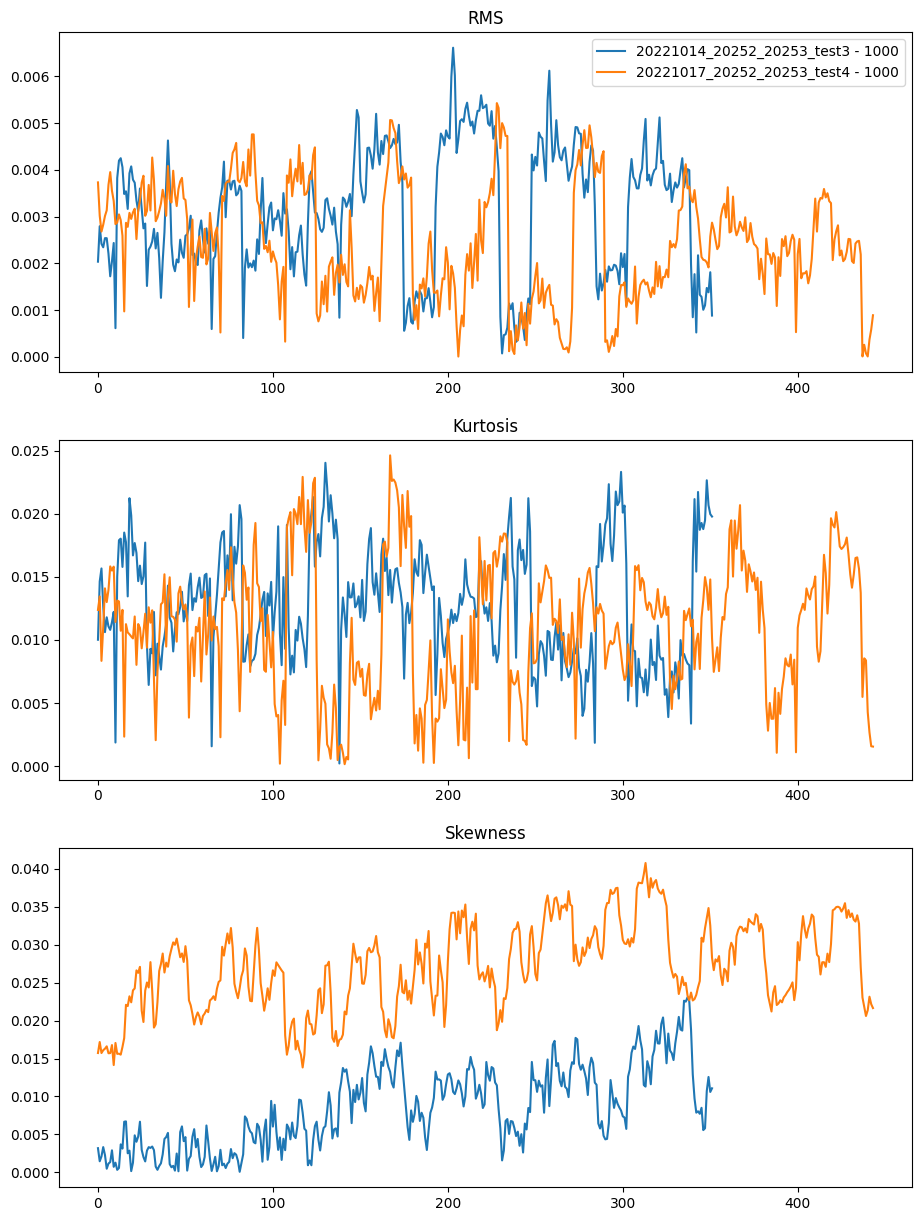

In [19]:
run_list = [
    [  # 20252
        {
            "folder": "20221014_20252_20253_test3",
            "position": 1,
            "status": "healthy",
            "status_opposite": "healthy",
            "take": [0.3, 0.7],
            "speed": 1500,
            "load": 1000,
        },
        {
            "folder": "20221017_20252_20253_test4",
            "position": 1,
            "status": "healthy",
            "status_opposite": "healthy",
            "take": [0.3, 0.9],
            "speed": 1500,
            "load": 1000,
        },
    ],
]

fig, axs = plt.subplots(3, 1, figsize=(11, 15))
axs = axs.flatten()

axs[0].set_title("RMS")
axs[1].set_title("Kurtosis")
axs[2].set_title("Skewness")

P_rms = None
P_kurtosis = None
P_skew = None

for i, group in enumerate(run_list):
    for j, run in enumerate(group):
        TC = run["position"]
        gear = run["folder"].split("_")[TC]

        file_path = (
            data_folder / run["folder"] / f"TC{TC}_accelerometer_{sensor}_{gear}.mf4"
        )
        signal = _load_mf4(file_path)
        signal = signal[
            int(run["take"][0] * len(signal)) : int(run["take"][1] * len(signal))
        ]

        folded_signal = fold(signal, measurement_len)

        rms_signal = RMS(folded_signal)
        rms_signal = fold(rms_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        kurtosis_signal = kurtosis(folded_signal, axis=1)
        kurtosis_signal = fold(kurtosis_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        skew_signal = skew(folded_signal, axis=1)
        skew_signal = fold(skew_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        if j == 0:
            # if True:
            P_rms = rms_signal[: len(rms_signal) // 4].mean()
            P_kurtosis = kurtosis_signal[: len(kurtosis_signal) // 4].mean()
            P_skew = skew_signal[: len(skew_signal) // 4].mean()

            # rms_signal = rms_signal[50:]
            # kurtosis_signal = kurtosis_signal[50:]
            # skew_signal = skew_signal[50:]

        rms_diff = np.abs(rms_signal - P_rms)
        kurtosis_diff = np.abs(kurtosis_signal - P_kurtosis)
        skew_diff = np.abs(skew_signal - P_skew)

        axs[0].plot(rms_diff, label=f"{run['folder']} - {run['load']}")
        axs[1].plot(kurtosis_diff, label=f"{run['folder']} - {run['load']}")
        axs[2].plot(skew_diff, label=f"{run['folder']} - {run['load']}")

axs[0].legend()

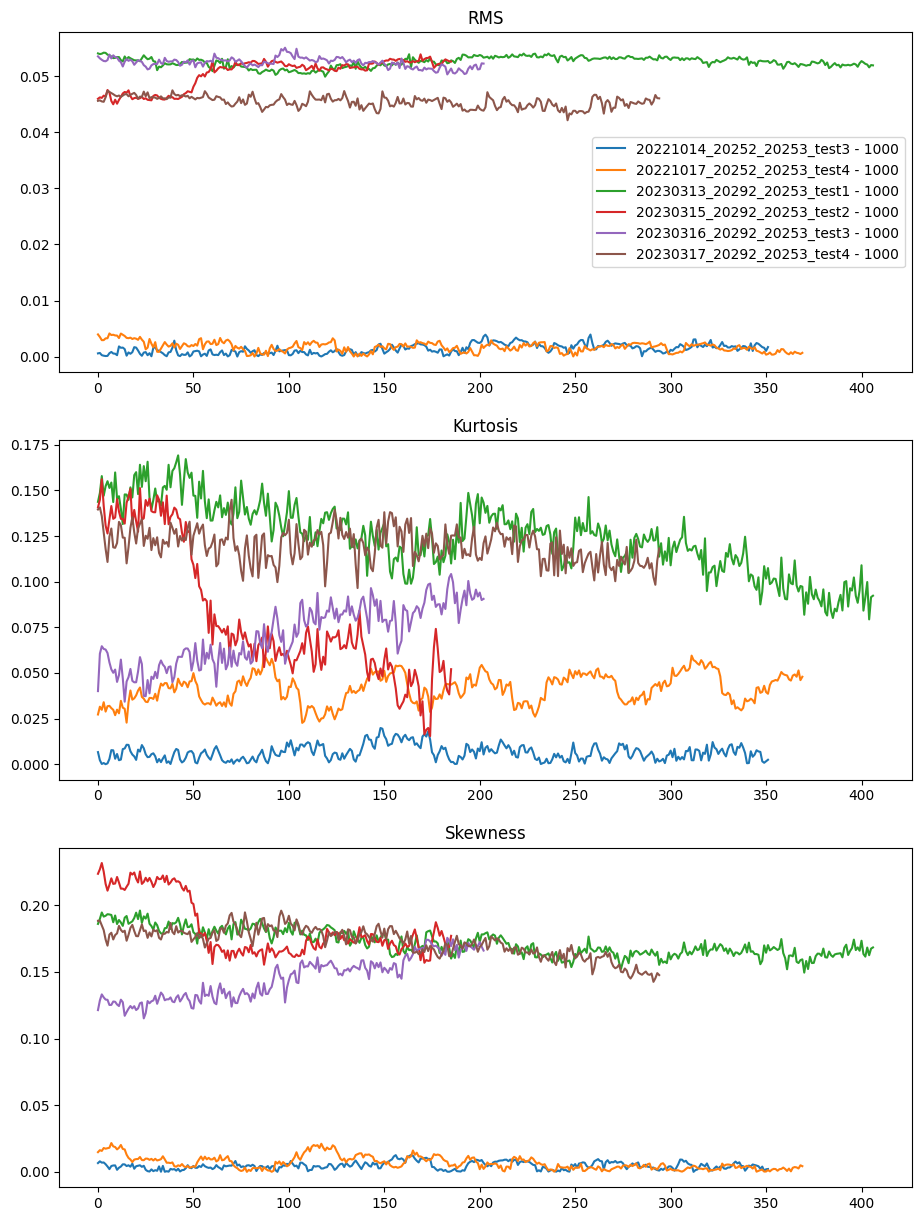

In [18]:
run_list = [
    [  # 20253
        {
            "folder": "20221014_20252_20253_test3",
            "position": 2,
            "status": "healthy",
            "status_opposite": "healthy",
            "take": [0.3, 0.7],
            "speed": 1500,
            "load": 1000,
        },
        {
            "folder": "20221017_20252_20253_test4",
            "position": 2,
            "status": "healthy",
            "status_opposite": "healthy",
            "take": [0.3, 0.8],
            "speed": 1500,
            "load": 1000,
        },
        # * Change of TC1 [20292]
        {
            "folder": "20230313_20292_20253_test1",
            "position": 2,
            "status": "W_indication",
            "status_opposite": "healthy",
            "take": [0.3, 0.8],
            "speed": 1500,
            "load": 1000,
        },
        {
            "folder": "20230315_20292_20253_test2",
            "position": 2,
            "status": "W_indication",
            "status_opposite": "healthy",
            "take": [0.3, 0.8],
            "speed": 1500,
            "load": 1000,
        },
        {
            "folder": "20230316_20292_20253_test3",
            "position": 2,
            "status": "W_indication",
            "status_opposite": "healthy",
            "take": [0.3, 0.8],
            "speed": 1500,
            "load": 1000,
        },
        {
            "folder": "20230317_20292_20253_test4",
            "position": 2,
            "status": "W_TIFF",
            "status_opposite": "healthy",
            "take": [0.3, 0.915],
            "speed": 1500,
            "load": 1000,
        },
    ],
]

fig, axs = plt.subplots(3, 1, figsize=(11, 15))
axs = axs.flatten()

axs[0].set_title("RMS")
axs[1].set_title("Kurtosis")
axs[2].set_title("Skewness")

P_rms = None
P_kurtosis = None
P_skew = None

for i, group in enumerate(run_list):
    for j, run in enumerate(group):
        TC = run["position"]
        gear = run["folder"].split("_")[TC]

        file_path = (
            data_folder / run["folder"] / f"TC{TC}_accelerometer_{sensor}_{gear}.mf4"
        )
        signal = _load_mf4(file_path)
        signal = signal[
            int(run["take"][0] * len(signal)) : int(run["take"][1] * len(signal))
        ]

        folded_signal = fold(signal, measurement_len)

        rms_signal = RMS(folded_signal)
        rms_signal = fold(rms_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        kurtosis_signal = kurtosis(folded_signal, axis=1)
        kurtosis_signal = fold(kurtosis_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        skew_signal = skew(folded_signal, axis=1)
        skew_signal = fold(skew_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        if j == 0:
            # if True:
            P_rms = rms_signal[: len(rms_signal) // 4].mean()
            P_kurtosis = kurtosis_signal[: len(kurtosis_signal) // 4].mean()
            P_skew = skew_signal[: len(skew_signal) // 4].mean()

            # rms_signal = rms_signal[50:]
            # kurtosis_signal = kurtosis_signal[50:]
            # skew_signal = skew_signal[50:]

        rms_diff = np.abs(rms_signal - P_rms)
        kurtosis_diff = np.abs(kurtosis_signal - P_kurtosis)
        skew_diff = np.abs(skew_signal - P_skew)

        axs[0].plot(rms_diff, label=f"{run['folder']} - {run['load']}")
        axs[1].plot(kurtosis_diff, label=f"{run['folder']} - {run['load']}")
        axs[2].plot(skew_diff, label=f"{run['folder']} - {run['load']}")

axs[0].legend()

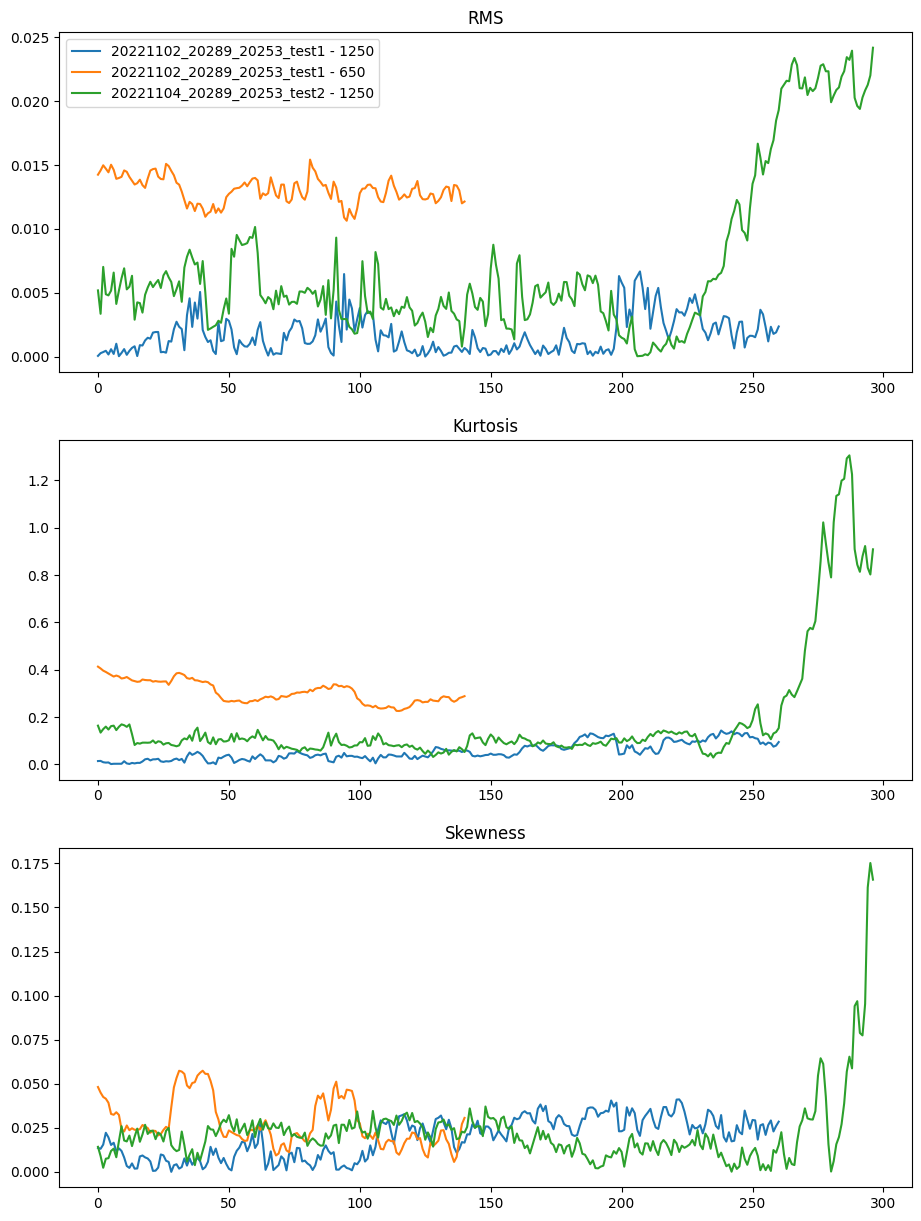

In [17]:
run_list = [
    [  # 20289
        {
            "folder": "20221102_20289_20253_test1",
            "position": 1,
            "status": "W_pre_indication",
            "status_opposite": "healthy",
            "take": [0.25, 0.6],
            "speed": 1500,
            "load": 1250,
        },
        {
            "folder": "20221102_20289_20253_test1",
            "position": 1,
            "status": "W_pre_indication",
            "status_opposite": "healthy",
            "take": [0.75, 0.94],
            "speed": 1500,
            "load": 650,
        },
        {  # ! FAULTY
            "folder": "20221104_20289_20253_test2",
            "position": 1,
            "status": "W_TIFF",
            "status_opposite": "healthy",
            "take": [0.3, 0.89],
            "speed": 1500,
            "load": 1250,
        },
    ],
]

fig, axs = plt.subplots(3, 1, figsize=(11, 15))
axs = axs.flatten()

axs[0].set_title("RMS")
axs[1].set_title("Kurtosis")
axs[2].set_title("Skewness")

P_rms = None
P_kurtosis = None
P_skew = None

for i, group in enumerate(run_list):
    for j, run in enumerate(group):
        TC = run["position"]
        gear = run["folder"].split("_")[TC]

        file_path = (
            data_folder / run["folder"] / f"TC{TC}_accelerometer_{sensor}_{gear}.mf4"
        )
        signal = _load_mf4(file_path)
        signal = signal[
            int(run["take"][0] * len(signal)) : int(run["take"][1] * len(signal))
        ]

        folded_signal = fold(signal, measurement_len)

        rms_signal = RMS(folded_signal)
        rms_signal = fold(rms_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        kurtosis_signal = kurtosis(folded_signal, axis=1)
        kurtosis_signal = fold(kurtosis_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        skew_signal = skew(folded_signal, axis=1)
        skew_signal = fold(skew_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        if j == 0:
            # if True:
            P_rms = rms_signal[: len(rms_signal) // 4].mean()
            P_kurtosis = kurtosis_signal[: len(kurtosis_signal) // 4].mean()
            P_skew = skew_signal[: len(skew_signal) // 4].mean()

            # rms_signal = rms_signal[50:]
            # kurtosis_signal = kurtosis_signal[50:]
            # skew_signal = skew_signal[50:]

        rms_diff = np.abs(rms_signal - P_rms)
        kurtosis_diff = np.abs(kurtosis_signal - P_kurtosis)
        skew_diff = np.abs(skew_signal - P_skew)

        axs[0].plot(rms_diff, label=f"{run['folder']} - {run['load']}")
        axs[1].plot(kurtosis_diff, label=f"{run['folder']} - {run['load']}")
        axs[2].plot(skew_diff, label=f"{run['folder']} - {run['load']}")

axs[0].legend()

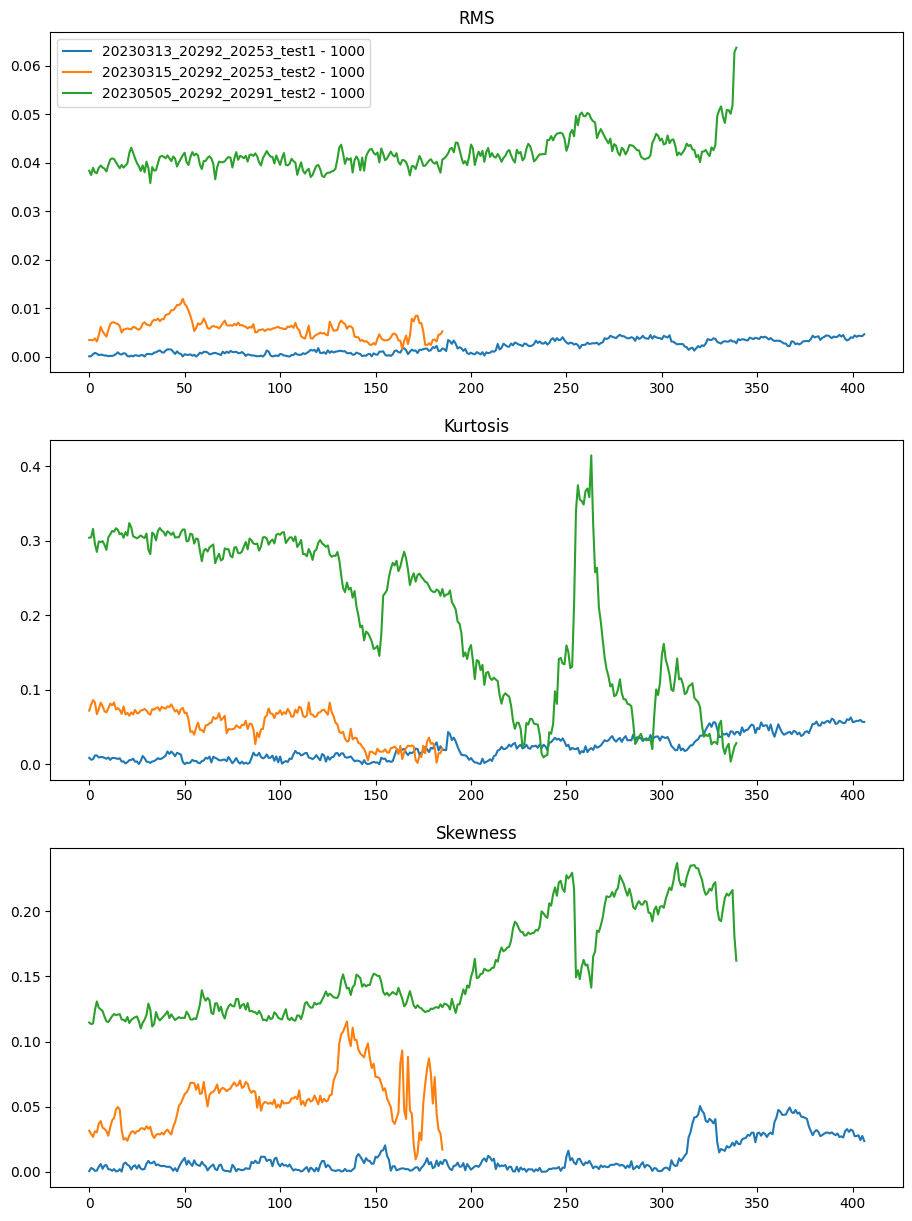

In [16]:
run_list = [
    # [  # 20290
    #     {  # * Healthy prototype
    #         "folder": "20221116_20290_20253_test1",
    #         "position": 1,
    #         "status": "healthy",
    #         "status_opposite": "healthy",
    #         "take": [0.2, 0.7],
    #         "speed": 1500,
    #         "load": 1125,
    #     },
    #     {  # ! Faulty prototype
    #         "folder": "20221121_20290_20253_test3",
    #         "position": 1,
    #         "status": "W_TIFF",
    #         "status_opposite": "W_pre_indication",
    #         "take": [0.3, 0.9],
    #         "speed": 1500,
    #         "load": 1125,
    #     },
    #     {
    #         "folder": "20221118_20290_20253_test2",
    #         "position": 1,
    #         "status": "W_pre_indication",
    #         "status_opposite": "healthy",
    #         "take": [0.3, 0.8],
    #         "speed": 1500,
    #         "load": 1125,
    #     },
    # ],
    [  # 20292
        {
            "folder": "20230313_20292_20253_test1",
            "position": 1,
            "status": "healthy",
            "status_opposite": "W_indication",
            "take": [0.3, 0.8],
            "speed": 1500,
            "load": 1000,
        },
        {
            "folder": "20230315_20292_20253_test2",
            "position": 1,
            "status": "healthy",
            "status_opposite": "W_indication",
            "take": [0.3, 0.8],
            "speed": 1500,
            "load": 1000,
        },
        # # Switch of TC2
        # {
        #     "folder": "20230503_20292_20291_test1",
        #     "position": 1,
        #     "status": "W_pre_indication",
        #     "status_opposite": "healthy",
        #     "take": [0.3, 0.8],
        #     "speed": 1500,
        #     "load": 1000,
        # },
        {  # ! FAULTY
            "folder": "20230505_20292_20291_test2",
            "position": 1,
            "status": "W_TIFF",
            "status_opposite": "healthy",
            "take": [0.3, 0.675],
            "speed": 1500,
            "load": 1000,
        },
    ],
]

fig, axs = plt.subplots(3, 1, figsize=(11, 15))
axs = axs.flatten()

axs[0].set_title("RMS")
axs[1].set_title("Kurtosis")
axs[2].set_title("Skewness")

P_rms = None
P_kurtosis = None
P_skew = None

for i, group in enumerate(run_list):
    for j, run in enumerate(group):
        TC = run["position"]
        gear = run["folder"].split("_")[TC]

        file_path = (
            data_folder / run["folder"] / f"TC{TC}_accelerometer_{sensor}_{gear}.mf4"
        )
        signal = _load_mf4(file_path)
        signal = signal[
            int(run["take"][0] * len(signal)) : int(run["take"][1] * len(signal))
        ]

        folded_signal = fold(signal, measurement_len)

        rms_signal = RMS(folded_signal)
        rms_signal = fold(rms_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        kurtosis_signal = kurtosis(folded_signal, axis=1)
        kurtosis_signal = fold(kurtosis_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        skew_signal = skew(folded_signal, axis=1)
        skew_signal = fold(skew_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        if j == 0:
            # if True:
            P_rms = rms_signal[: len(rms_signal) // 4].mean()
            P_kurtosis = kurtosis_signal[: len(kurtosis_signal) // 4].mean()
            P_skew = skew_signal[: len(skew_signal) // 4].mean()

            # rms_signal = rms_signal[50:]
            # kurtosis_signal = kurtosis_signal[50:]
            # skew_signal = skew_signal[50:]

        rms_diff = np.abs(rms_signal - P_rms)
        kurtosis_diff = np.abs(kurtosis_signal - P_kurtosis)
        skew_diff = np.abs(skew_signal - P_skew)

        axs[0].plot(rms_diff, label=f"{run['folder']} - {run['load']}")
        axs[1].plot(kurtosis_diff, label=f"{run['folder']} - {run['load']}")
        axs[2].plot(skew_diff, label=f"{run['folder']} - {run['load']}")

axs[0].legend()

---


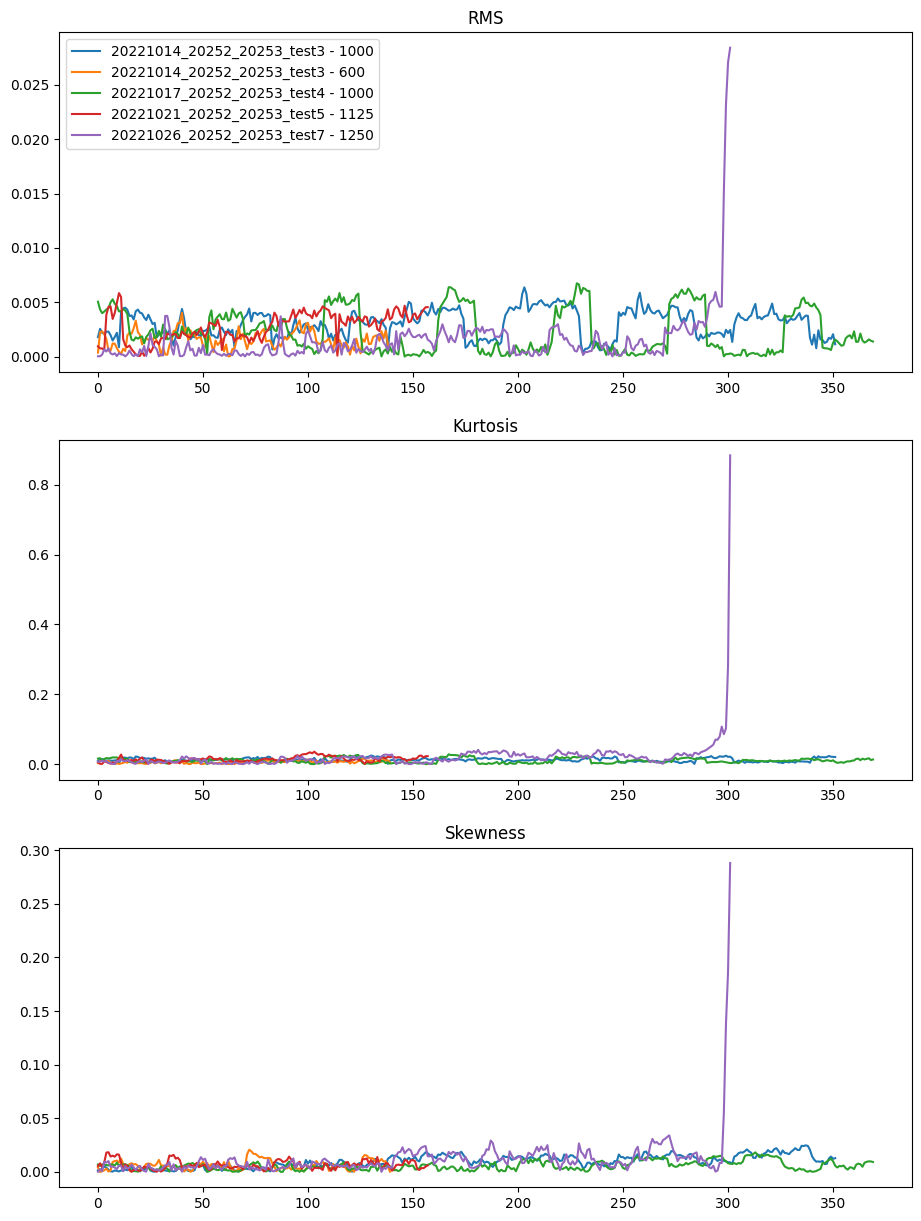

In [9]:
run_list = [
    [  # * 20252 [ALL LOADS]
        {
            "folder": "20221014_20252_20253_test3",
            "position": 1,
            "status": "healthy",
            "status_opposite": "healthy",
            "take": [0.3, 0.7],
            "speed": 1500,
            "load": 1000,
        },
        {  # * LOAD 600
            "folder": "20221014_20252_20253_test3",
            "position": 1,
            "status": "healthy",
            "status_opposite": "healthy",
            "take": [0.82, 0.98],
            "speed": 1500,
            "load": 600,
        },
        {
            "folder": "20221017_20252_20253_test4",
            "position": 1,
            "status": "healthy",
            "status_opposite": "healthy",
            "take": [0.3, 0.8],
            "speed": 1500,
            "load": 1000,
        },
        {  # * LOAD 1125 & P_pre_indication
            "folder": "20221021_20252_20253_test5",
            "position": 1,
            "status": "P_pre_indication",
            "status_opposite": "healthy",
            "take": [0.3, 0.75],
            "speed": 1500,
            "load": 1125,
        },
        {  # * LOAD 1250 & PINION_TFF
            "folder": "20221026_20252_20253_test7",
            "position": 1,
            "status": "P_TIFF",
            "status_opposite": "healthy",
            "take": [0.3, 0.98],
            "speed": 1500,
            "load": 1250,
        },
    ],
]

fig, axs = plt.subplots(3, 1, figsize=(11, 15))
axs = axs.flatten()

axs[0].set_title("RMS")
axs[1].set_title("Kurtosis")
axs[2].set_title("Skewness")

P_rms = None
P_kurtosis = None
P_skew = None

for group in run_list:
    for i, run in enumerate(group):
        TC = run["position"]
        gear = run["folder"].split("_")[TC]

        file_path = (
            data_folder / run["folder"] / f"TC{TC}_accelerometer_{sensor}_{gear}.mf4"
        )
        signal = _load_mf4(file_path)
        signal = signal[
            int(run["take"][0] * len(signal)) : int(run["take"][1] * len(signal))
        ]

        folded_signal = fold(signal, measurement_len)

        rms_signal = RMS(folded_signal)
        rms_signal = fold(rms_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        kurtosis_signal = kurtosis(folded_signal, axis=1)
        kurtosis_signal = fold(kurtosis_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        skew_signal = skew(folded_signal, axis=1)
        skew_signal = fold(skew_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        # if i == 0:
        if True:
            P_rms = rms_signal[:50].mean()
            P_kurtosis = kurtosis_signal[:50].mean()
            P_skew = skew_signal[:50].mean()

            # rms_signal = rms_signal[50:]
            # kurtosis_signal = kurtosis_signal[50:]
            # skew_signal = skew_signal[50:]

        rms_diff = np.abs(rms_signal - P_rms)
        kurtosis_diff = np.abs(kurtosis_signal - P_kurtosis)
        skew_diff = np.abs(skew_signal - P_skew)

        axs[0].plot(rms_diff, label=f"{run['folder']} - {run['load']}")
        axs[1].plot(kurtosis_diff, label=f"{run['folder']} - {run['load']}")
        axs[2].plot(skew_diff, label=f"{run['folder']} - {run['load']}")

axs[0].legend()

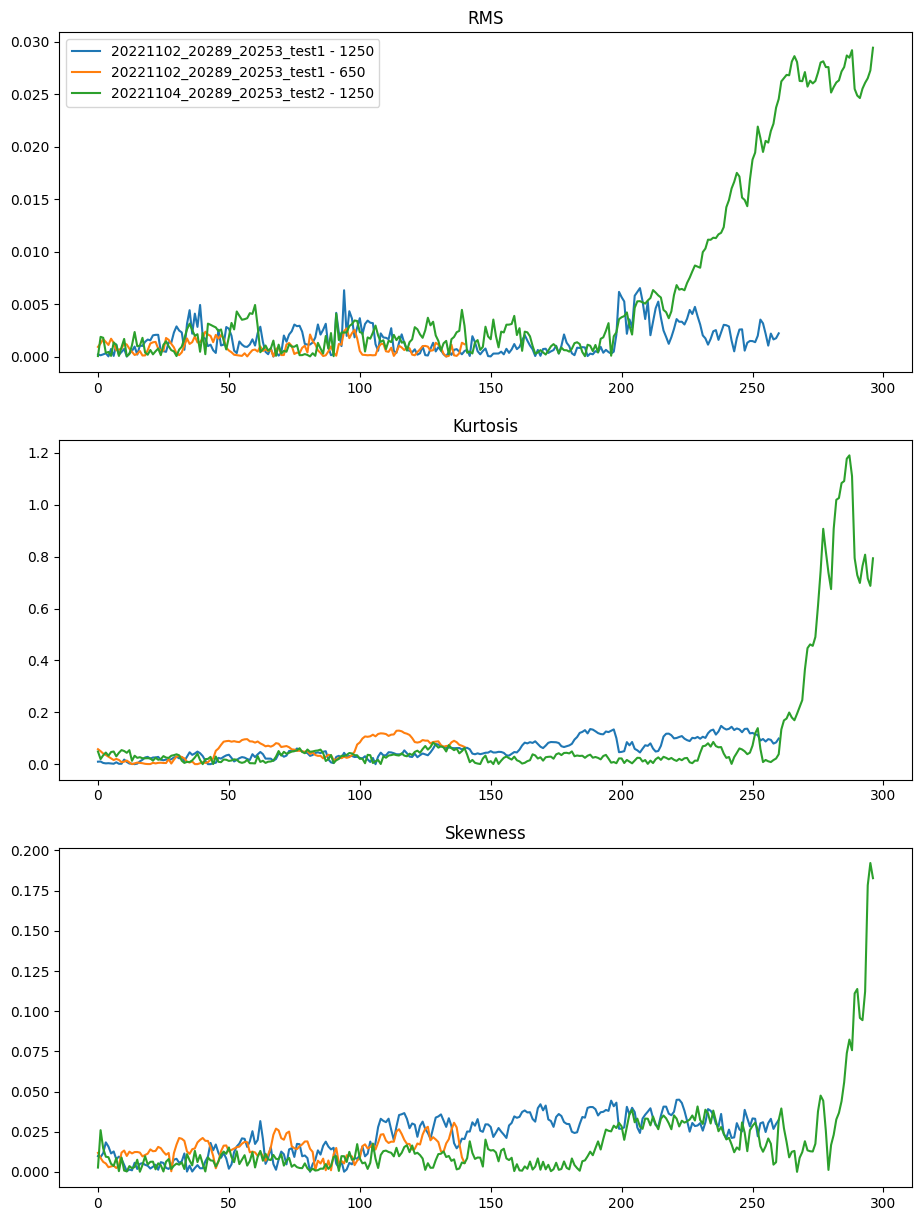

In [10]:
# GOOD 1 - 20289
run_list = [
    [  # 20289 [1250 & 650]
        {
            "folder": "20221102_20289_20253_test1",
            "position": 1,
            "status": "W_pre_indication",
            "status_opposite": "healthy",
            "take": [0.25, 0.6],
            "speed": 1500,
            "load": 1250,
        },
        {
            "folder": "20221102_20289_20253_test1",
            "position": 1,
            "status": "W_pre_indication",
            "status_opposite": "healthy",
            "take": [0.75, 0.94],
            "speed": 1500,
            "load": 650,
        },
        {
            "folder": "20221104_20289_20253_test2",
            "position": 1,
            "status": "W_TIFF",
            "status_opposite": "healthy",
            "take": [0.3, 0.89],
            "speed": 1500,
            "load": 1250,
        },
    ],
]

fig, axs = plt.subplots(3, 1, figsize=(11, 15))
axs = axs.flatten()

axs[0].set_title("RMS")
axs[1].set_title("Kurtosis")
axs[2].set_title("Skewness")

P_rms = None
P_kurtosis = None
P_skew = None

for group in run_list:
    for i, run in enumerate(group):
        TC = run["position"]
        gear = run["folder"].split("_")[TC]

        file_path = (
            data_folder / run["folder"] / f"TC{TC}_accelerometer_{sensor}_{gear}.mf4"
        )
        signal = _load_mf4(file_path)
        signal = signal[
            int(run["take"][0] * len(signal)) : int(run["take"][1] * len(signal))
        ]

        folded_signal = fold(signal, measurement_len)

        rms_signal = RMS(folded_signal)
        rms_signal = fold(rms_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        kurtosis_signal = kurtosis(folded_signal, axis=1)
        kurtosis_signal = fold(kurtosis_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        skew_signal = skew(folded_signal, axis=1)
        skew_signal = fold(skew_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        # if i == 0:
        if True:
            P_rms = rms_signal[:50].mean()
            P_kurtosis = kurtosis_signal[:50].mean()
            P_skew = skew_signal[:50].mean()

            # rms_signal = rms_signal[50:]
            # kurtosis_signal = kurtosis_signal[50:]
            # skew_signal = skew_signal[50:]

        rms_diff = np.abs(rms_signal - P_rms)
        kurtosis_diff = np.abs(kurtosis_signal - P_kurtosis)
        skew_diff = np.abs(skew_signal - P_skew)

        axs[0].plot(rms_diff, label=f"{run['folder']} - {run['load']}")
        axs[1].plot(kurtosis_diff, label=f"{run['folder']} - {run['load']}")
        axs[2].plot(skew_diff, label=f"{run['folder']} - {run['load']}")

axs[0].legend()

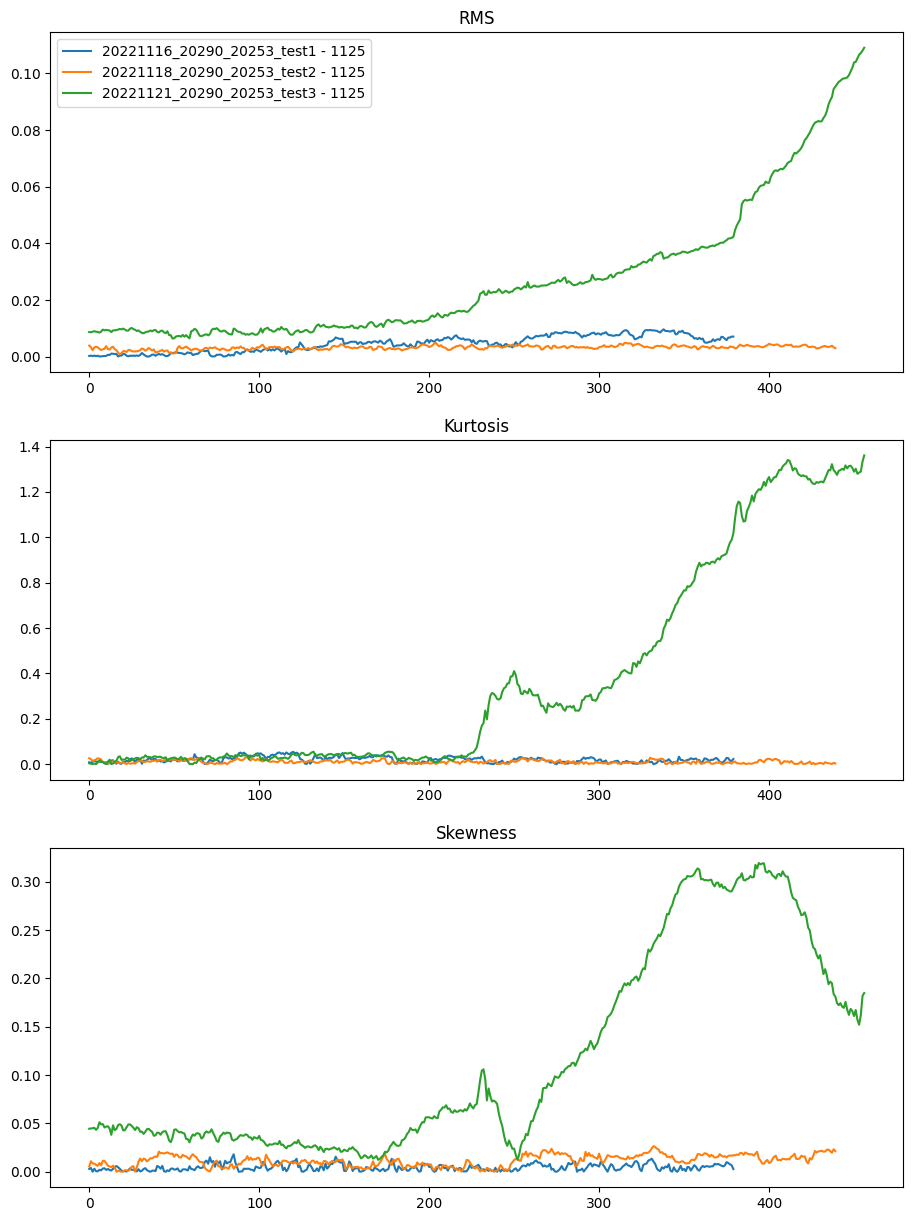

In [14]:
# GOOD 2 - 20290
run_list = [
    [  # 20290 [1125 & 650]
        {
            "folder": "20221116_20290_20253_test1",
            "position": 1,
            "status": "healthy",
            "status_opposite": "healthy",
            "take": [0.2, 0.7],
            "speed": 1500,
            "load": 1125,
        },
        # {
        #     "folder": "20221116_20290_20253_test1",
        #     "position": 1,
        #     "status": "healthy",
        #     "status_opposite": "healthy",
        #     "take": [0.77, 0.97],
        #     "speed": 1500,
        #     "load": 650,
        # },
        {
            "folder": "20221118_20290_20253_test2",
            "position": 1,
            "status": "W_pre_indication",
            "status_opposite": "healthy",
            "take": [0.3, 0.8],
            "speed": 1500,
            "load": 1125,
        },
        {
            "folder": "20221121_20290_20253_test3",
            "position": 1,
            "status": "W_TIFF",
            "status_opposite": "W_pre_indication",
            "take": [0.3, 0.9],
            "speed": 1500,
            "load": 1125,
        },
    ],
]

fig, axs = plt.subplots(3, 1, figsize=(11, 15))
axs = axs.flatten()

axs[0].set_title("RMS")
axs[1].set_title("Kurtosis")
axs[2].set_title("Skewness")

P_rms = None
P_kurtosis = None
P_skew = None

for group in run_list:
    for i, run in enumerate(group):
        TC = run["position"]
        gear = run["folder"].split("_")[TC]

        file_path = (
            data_folder / run["folder"] / f"TC{TC}_accelerometer_{sensor}_{gear}.mf4"
        )
        signal = _load_mf4(file_path)
        signal = signal[
            int(run["take"][0] * len(signal)) : int(run["take"][1] * len(signal))
        ]

        folded_signal = fold(signal, measurement_len)

        rms_signal = RMS(folded_signal)
        rms_signal = fold(rms_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        kurtosis_signal = kurtosis(folded_signal, axis=1)
        kurtosis_signal = fold(kurtosis_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        skew_signal = skew(folded_signal, axis=1)
        skew_signal = fold(skew_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        if i == 0:
            # if True:
            P_rms = rms_signal[:50].mean()
            P_kurtosis = kurtosis_signal[:50].mean()
            P_skew = skew_signal[:50].mean()

            # rms_signal = rms_signal[50:]
            # kurtosis_signal = kurtosis_signal[50:]
            # skew_signal = skew_signal[50:]

        rms_diff = np.abs(rms_signal - P_rms)
        kurtosis_diff = np.abs(kurtosis_signal - P_kurtosis)
        skew_diff = np.abs(skew_signal - P_skew)

        axs[0].plot(rms_diff, label=f"{run['folder']} - {run['load']}")
        axs[1].plot(kurtosis_diff, label=f"{run['folder']} - {run['load']}")
        axs[2].plot(skew_diff, label=f"{run['folder']} - {run['load']}")

axs[0].legend()

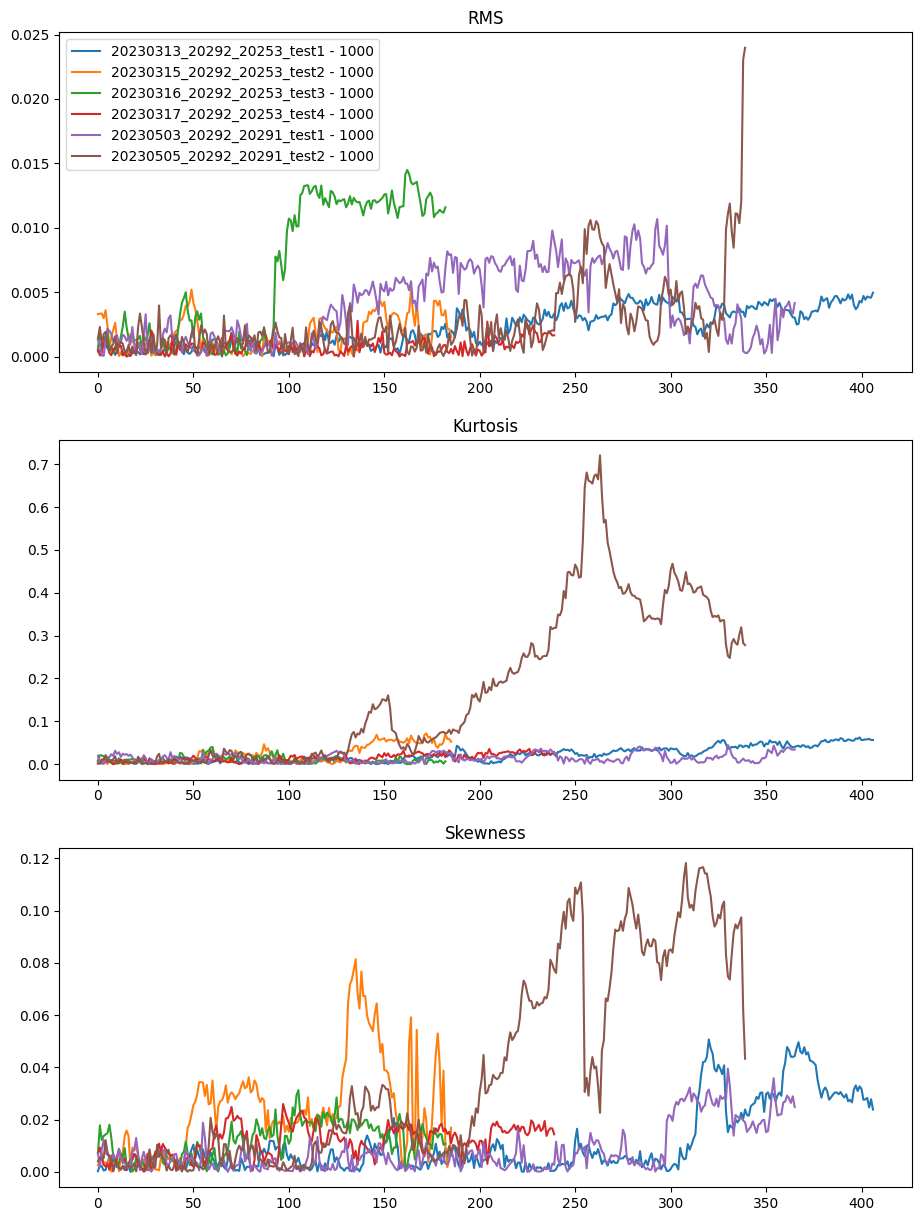

In [12]:
# GOOD 3 - 20292
run_list = [
    [  # 20292 [1125 & 650]
        {
            "folder": "20230313_20292_20253_test1",
            "position": 1,
            "status": "healthy",
            "status_opposite": "W_indication",
            "take": [0.3, 0.8],
            "speed": 1500,
            "load": 1000,
        },
        {
            "folder": "20230315_20292_20253_test2",
            "position": 1,
            "status": "healthy",
            "status_opposite": "W_indication",
            "take": [0.3, 0.8],
            "speed": 1500,
            "load": 1000,
        },
        {
            "folder": "20230316_20292_20253_test3",
            "position": 1,
            "status": "healthy",
            "status_opposite": "W_indication",
            "take": [0.3, 0.75],
            "speed": 1500,
            "load": 1000,
        },
        {
            "folder": "20230317_20292_20253_test4",
            "position": 1,
            "status": "healthy",
            "status_opposite": "W_TIFF",
            "take": [0.3, 0.8],
            "speed": 1500,
            "load": 1000,
        },
    ],
    [
        #
        {
            "folder": "20230503_20292_20291_test1",
            "position": 1,
            "status": "W_pre_indication",
            "status_opposite": "healthy",
            "take": [0.3, 0.8],
            "speed": 1500,
            "load": 1000,
        },
        {
            "folder": "20230505_20292_20291_test2",
            "position": 1,
            "status": "W_TIFF",
            "status_opposite": "healthy",
            "take": [0.3, 0.675],
            "speed": 1500,
            "load": 1000,
        },
    ],
]

fig, axs = plt.subplots(3, 1, figsize=(11, 15))
axs = axs.flatten()

axs[0].set_title("RMS")
axs[1].set_title("Kurtosis")
axs[2].set_title("Skewness")

P_rms = None
P_kurtosis = None
P_skew = None

for group in run_list:
    for i, run in enumerate(group):
        TC = run["position"]
        gear = run["folder"].split("_")[TC]

        file_path = (
            data_folder / run["folder"] / f"TC{TC}_accelerometer_{sensor}_{gear}.mf4"
        )
        signal = _load_mf4(file_path)
        signal = signal[
            int(run["take"][0] * len(signal)) : int(run["take"][1] * len(signal))
        ]

        folded_signal = fold(signal, measurement_len)

        rms_signal = RMS(folded_signal)
        rms_signal = fold(rms_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        kurtosis_signal = kurtosis(folded_signal, axis=1)
        kurtosis_signal = fold(kurtosis_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        skew_signal = skew(folded_signal, axis=1)
        skew_signal = fold(skew_signal, window_len).mean(
            axis=-1
        )  # Average over window_len windows for smoother plot

        if i == 0:
            # if True:
            P_rms = rms_signal[:50].mean()
            P_kurtosis = kurtosis_signal[:50].mean()
            P_skew = skew_signal[:50].mean()

            # rms_signal = rms_signal[50:]
            # kurtosis_signal = kurtosis_signal[50:]
            # skew_signal = skew_signal[50:]

        rms_diff = np.abs(rms_signal - P_rms)
        kurtosis_diff = np.abs(kurtosis_signal - P_kurtosis)
        skew_diff = np.abs(skew_signal - P_skew)

        axs[0].plot(rms_diff, label=f"{run['folder']} - {run['load']}")
        axs[1].plot(kurtosis_diff, label=f"{run['folder']} - {run['load']}")
        axs[2].plot(skew_diff, label=f"{run['folder']} - {run['load']}")

axs[0].legend()

## OLD


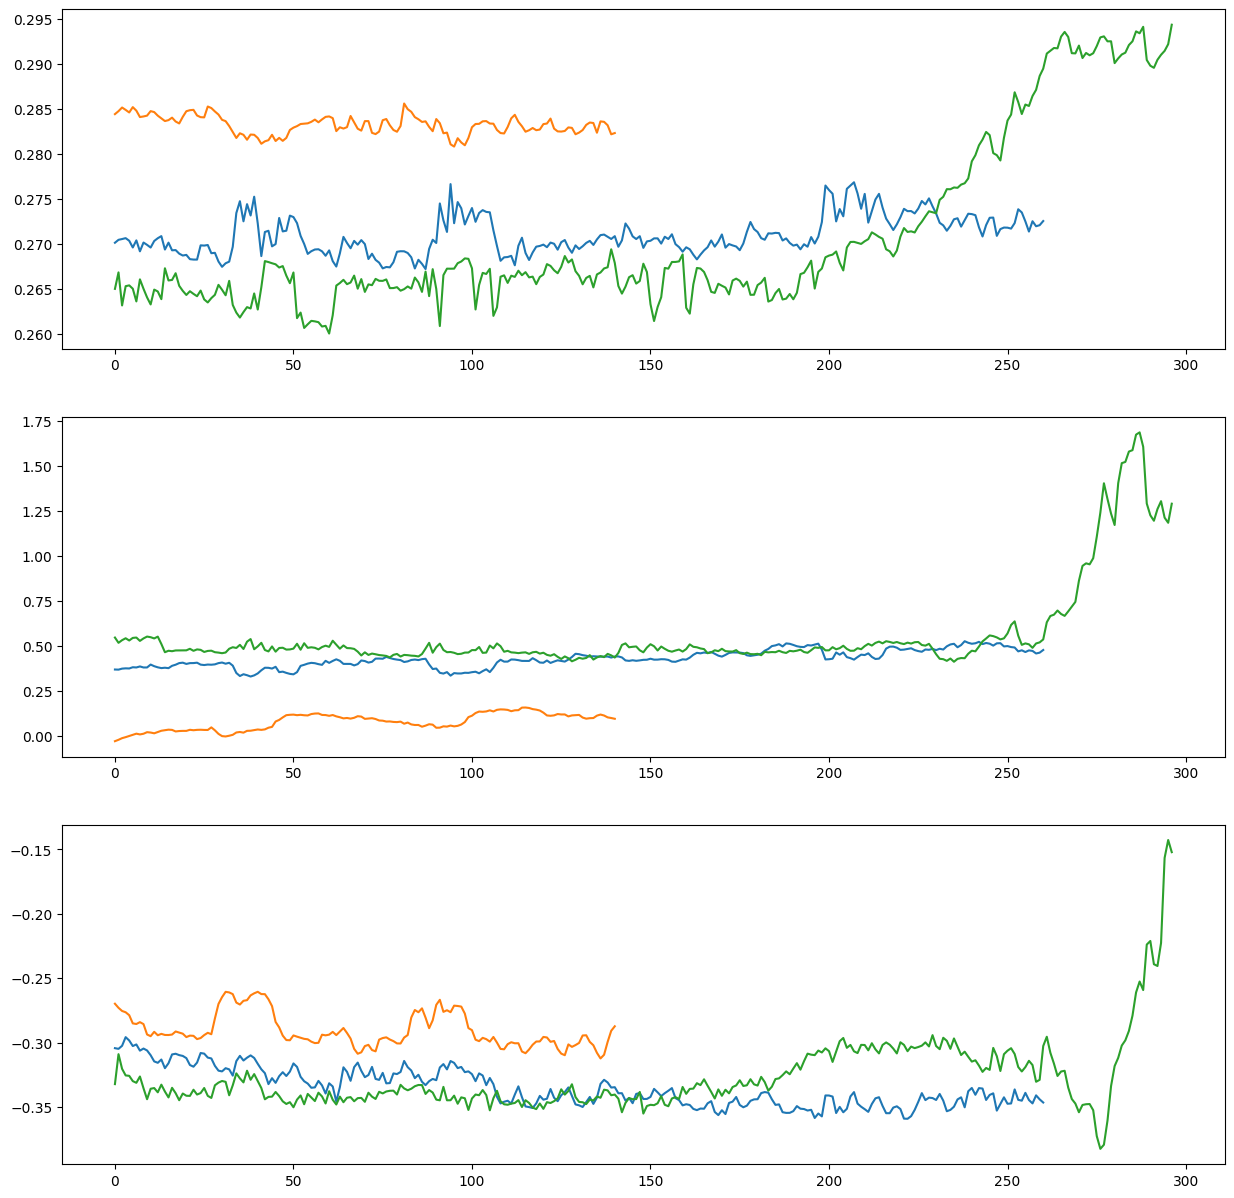

In [18]:
run_list = [
    {
        "folder": "20221102_20289_20253_test1",
        "position": 1,
        "status": "W_pre_indication",
        "status_opposite": "healthy",
        "take": [0.25, 0.6],
        "speed": 1500,
        "load": 1250,
    },
    {
        "folder": "20221102_20289_20253_test1",
        "position": 1,
        "status": "W_pre_indication",
        "status_opposite": "healthy",
        "take": [0.75, 0.94],
        "speed": 1500,
        "load": 650,
    },
    {
        "folder": "20221104_20289_20253_test2",
        "position": 1,
        "status": "W_TIFF",
        "status_opposite": "healthy",
        "take": [0.3, 0.89],
        "speed": 1500,
        "load": 1250,
    },
]

fig, axs = plt.subplots(3, 1, figsize=(15, 15))
axs = axs.flatten()


for run in run_list:
    TC = run["position"]
    gear = run["folder"].split("_")[TC]

    file_path = (
        data_folder / run["folder"] / f"TC{TC}_accelerometer_{sensor}_{gear}.mf4"
    )
    signal = _load_mf4(file_path)
    signal = signal[
        int(run["take"][0] * len(signal)) : int(run["take"][1] * len(signal))
    ]

    folded_signal = fold(signal, window_len)

    rms_signal = RMS(folded_signal)
    rms_signal = fold(rms_signal, 50).mean(
        axis=-1
    )  # Average over 50 windows for smoother plot

    kurtosis_signal = kurtosis(folded_signal, axis=1)
    kurtosis_signal = fold(kurtosis_signal, 50).mean(
        axis=-1
    )  # Average over 50 windows for smoother plot

    skew_signal = skew(folded_signal, axis=1)
    skew_signal = fold(skew_signal, 50).mean(
        axis=-1
    )  # Average over 50 windows for smoother plot

    axs[0].plot(rms_signal, label=f"{run['folder']} - {run['load']}")
    axs[1].plot(kurtosis_signal, label=f"{run['folder']} - {run['load']}")
    axs[2].plot(skew_signal, label=f"{run['folder']} - {run['load']}")

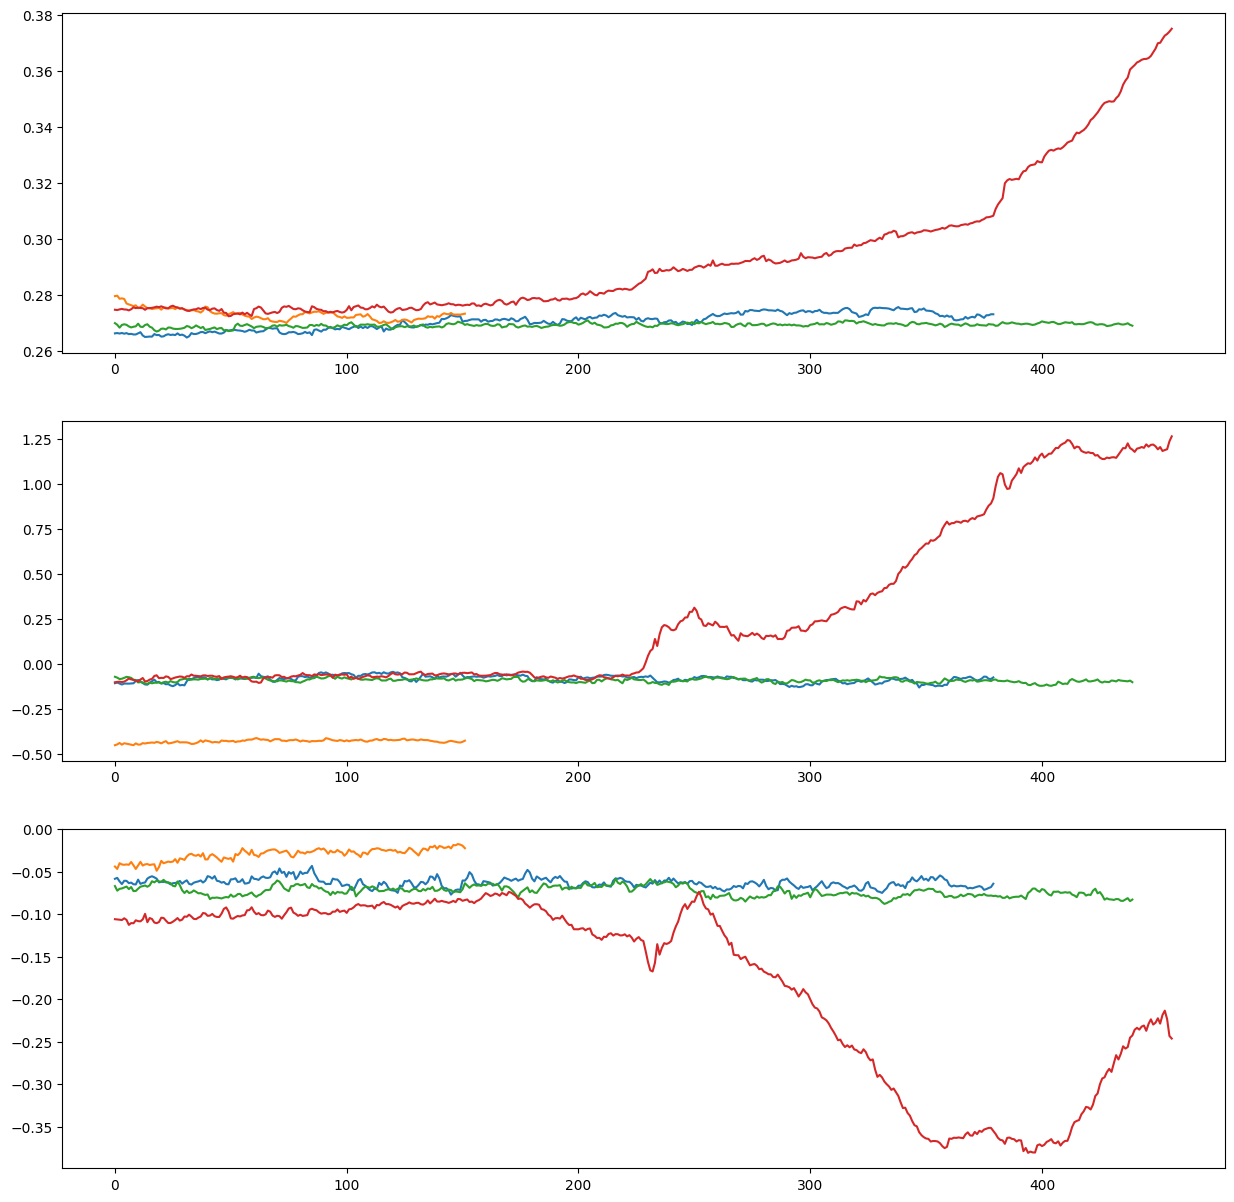

In [19]:
run_list = [
    {
        "folder": "20221116_20290_20253_test1",
        "position": 1,
        "status": "healthy",
        "status_opposite": "healthy",
        "take": [0.2, 0.7],
        "speed": 1500,
        "load": 1125,
    },
    {
        "folder": "20221116_20290_20253_test1",
        "position": 1,
        "status": "healthy",
        "status_opposite": "healthy",
        "take": [0.77, 0.97],
        "speed": 1500,
        "load": 650,
    },
    {
        "folder": "20221118_20290_20253_test2",
        "position": 1,
        "status": "W_pre_indication",
        "status_opposite": "healthy",
        "take": [0.3, 0.8],
        "speed": 1500,
        "load": 1125,
    },
    {
        "folder": "20221121_20290_20253_test3",
        "position": 1,
        "status": "W_TIFF",
        "status_opposite": "W_pre_indication",
        "take": [0.3, 0.9],
        "speed": 1500,
        "load": 1125,
    },
]


fig, axs = plt.subplots(3, 1, figsize=(15, 15))
axs = axs.flatten()


for run in run_list:
    TC = run["position"]
    gear = run["folder"].split("_")[TC]

    file_path = (
        data_folder / run["folder"] / f"TC{TC}_accelerometer_{sensor}_{gear}.mf4"
    )
    signal = _load_mf4(file_path)
    signal = signal[
        int(run["take"][0] * len(signal)) : int(run["take"][1] * len(signal))
    ]

    folded_signal = fold(signal, window_len)

    rms_signal = RMS(folded_signal)
    rms_signal = fold(rms_signal, 50).mean(
        axis=-1
    )  # Average over 50 windows for smoother plot

    kurtosis_signal = kurtosis(folded_signal, axis=1)
    kurtosis_signal = fold(kurtosis_signal, 50).mean(
        axis=-1
    )  # Average over 50 windows for smoother plot

    skew_signal = skew(folded_signal, axis=1)
    skew_signal = fold(skew_signal, 50).mean(
        axis=-1
    )  # Average over 50 windows for smoother plot

    axs[0].plot(rms_signal, label=f"{run['folder']} - {run['load']}")
    axs[1].plot(kurtosis_signal, label=f"{run['folder']} - {run['load']}")
    axs[2].plot(skew_signal, label=f"{run['folder']} - {run['load']}")

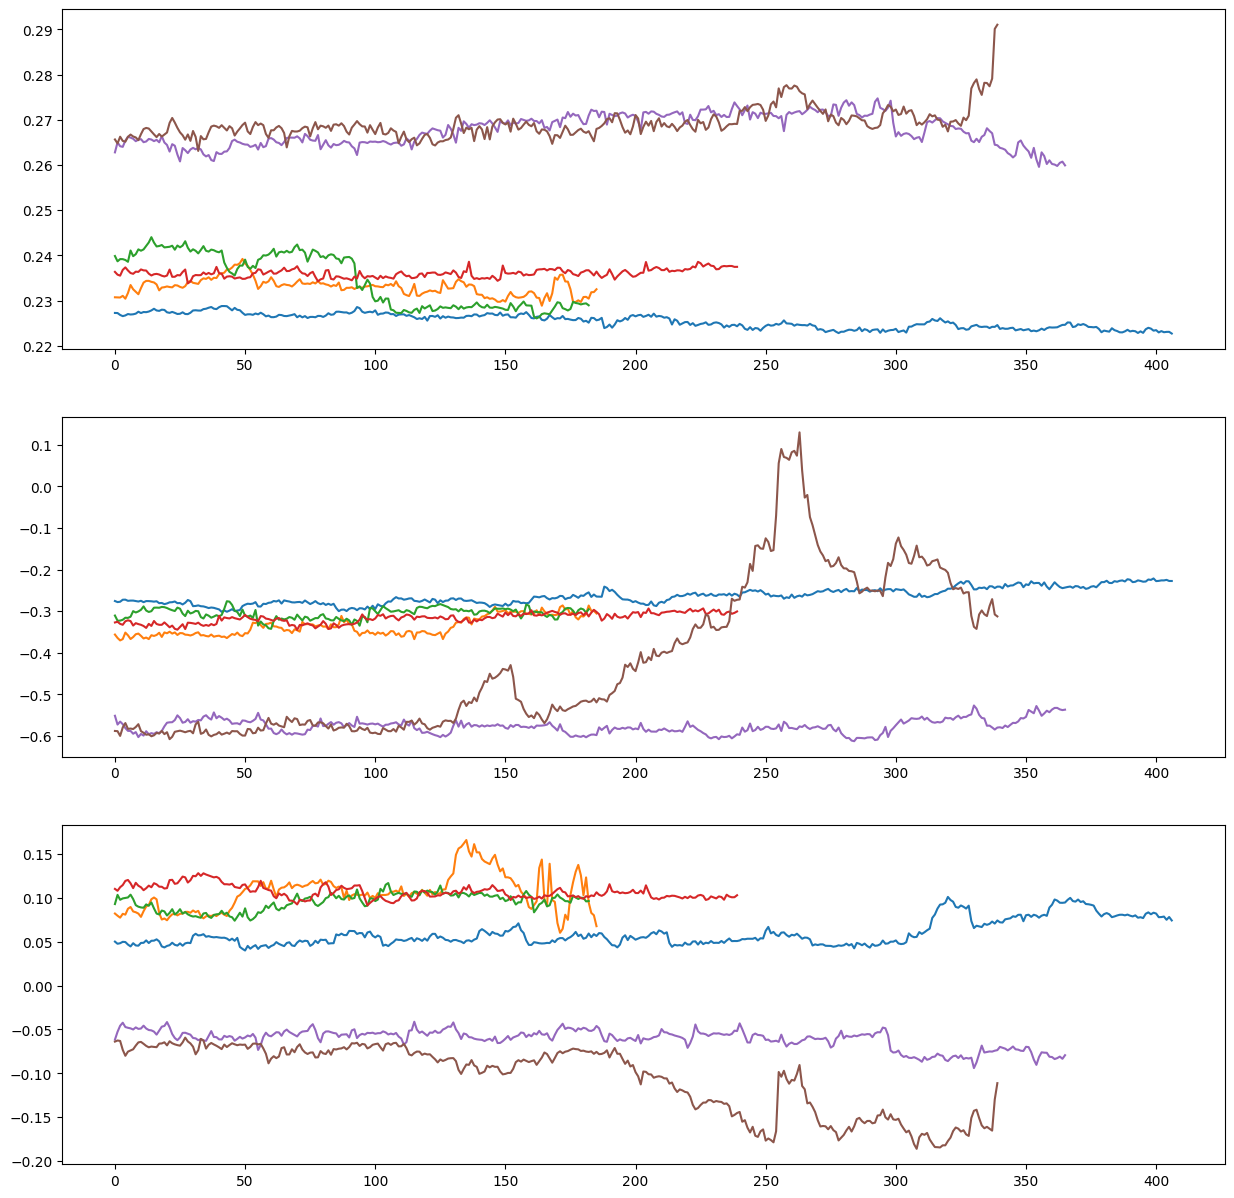

In [20]:
run_list = [
    {
        "folder": "20230313_20292_20253_test1",
        "position": 1,
        "status": "healthy",
        "status_opposite": "W_indication",
        "take": [0.3, 0.8],
        "speed": 1500,
        "load": 1000,
    },
    {
        "folder": "20230315_20292_20253_test2",
        "position": 1,
        "status": "healthy",
        "status_opposite": "W_indication",
        "take": [0.3, 0.8],
        "speed": 1500,
        "load": 1000,
    },
    {
        "folder": "20230316_20292_20253_test3",
        "position": 1,
        "status": "healthy",
        "status_opposite": "W_indication",
        "take": [0.3, 0.75],
        "speed": 1500,
        "load": 1000,
    },
    {
        "folder": "20230317_20292_20253_test4",
        "position": 1,
        "status": "healthy",
        "status_opposite": "W_TIFF",
        "take": [0.3, 0.8],
        "speed": 1500,
        "load": 1000,
    },
    #
    {
        "folder": "20230503_20292_20291_test1",
        "position": 1,
        "status": "W_pre_indication",
        "status_opposite": "healthy",
        "take": [0.3, 0.8],
        "speed": 1500,
        "load": 1000,
    },
    {
        "folder": "20230505_20292_20291_test2",
        "position": 1,
        "status": "W_TIFF",
        "status_opposite": "healthy",
        "take": [0.3, 0.675],
        "speed": 1500,
        "load": 1000,
    },
]


fig, axs = plt.subplots(3, 1, figsize=(15, 15))
axs = axs.flatten()


for run in run_list:
    TC = run["position"]
    gear = run["folder"].split("_")[TC]

    file_path = (
        data_folder / run["folder"] / f"TC{TC}_accelerometer_{sensor}_{gear}.mf4"
    )
    signal = _load_mf4(file_path)
    signal = signal[
        int(run["take"][0] * len(signal)) : int(run["take"][1] * len(signal))
    ]

    folded_signal = fold(signal, window_len)

    rms_signal = RMS(folded_signal)
    rms_signal = fold(rms_signal, 50).mean(
        axis=-1
    )  # Average over 50 windows for smoother plot

    kurtosis_signal = kurtosis(folded_signal, axis=1)
    kurtosis_signal = fold(kurtosis_signal, 50).mean(
        axis=-1
    )  # Average over 50 windows for smoother plot

    skew_signal = skew(folded_signal, axis=1)
    skew_signal = fold(skew_signal, 50).mean(
        axis=-1
    )  # Average over 50 windows for smoother plot

    axs[0].plot(rms_signal, label=f"{run['folder']} - {run['load']}")
    axs[1].plot(kurtosis_signal, label=f"{run['folder']} - {run['load']}")
    axs[2].plot(skew_signal, label=f"{run['folder']} - {run['load']}")

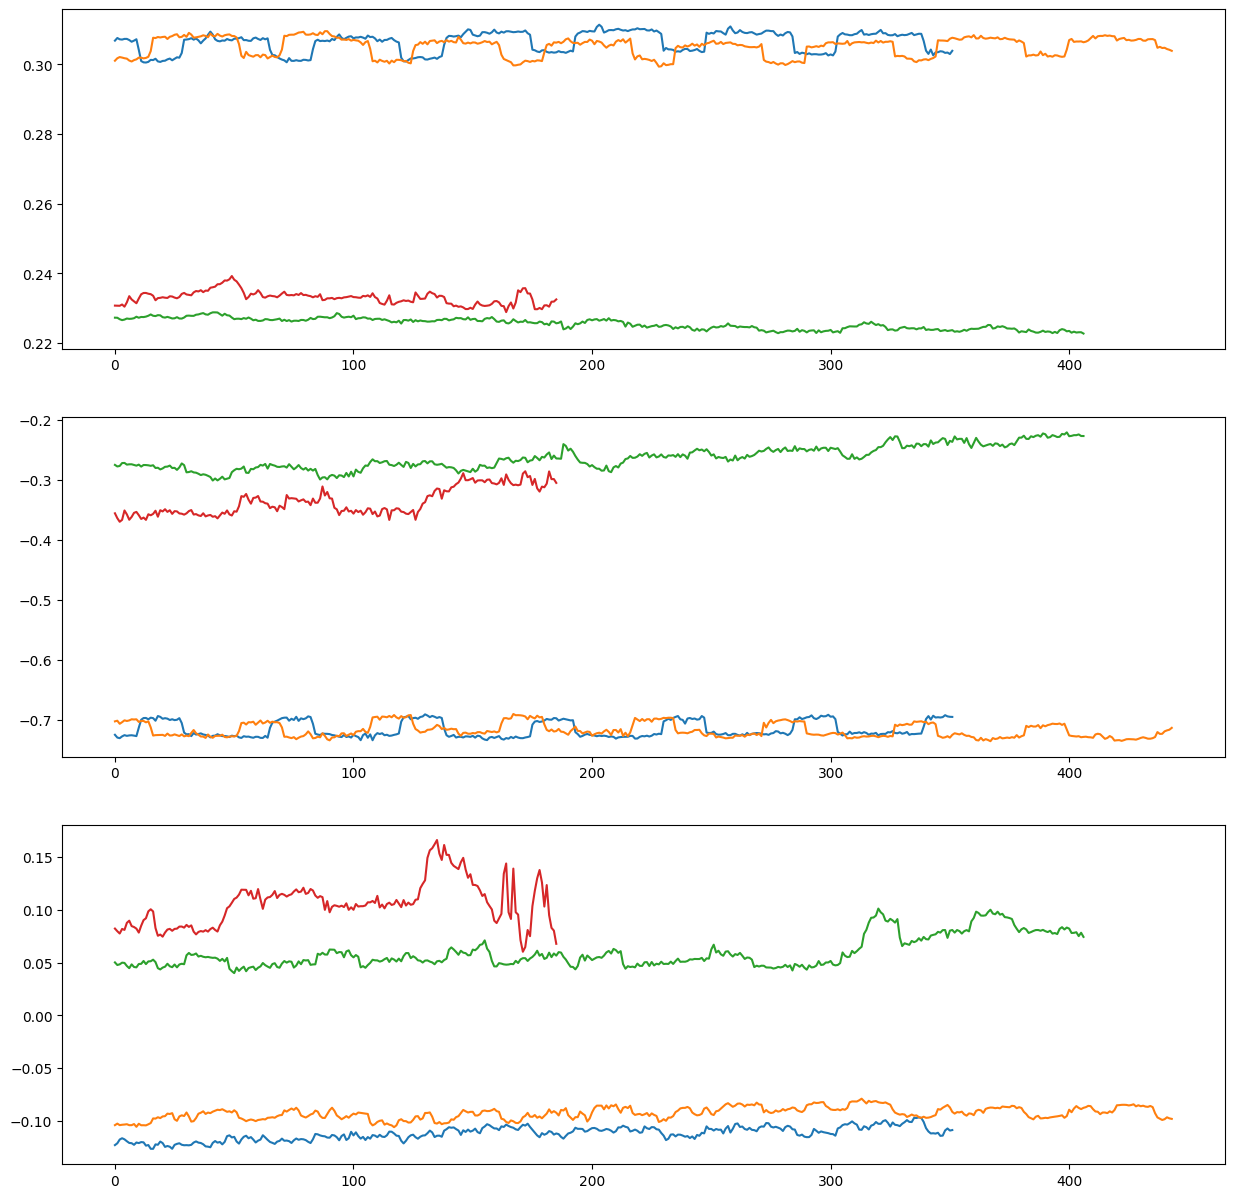

In [ ]:
# MIXED

run_list = [
    {
        "folder": "20221014_20252_20253_test3",
        "position": 1,
        "status": "healthy",
        "status_opposite": "healthy",
        "take": [0.3, 0.7],
        "load": 1000,
    },
    {
        "folder": "20221017_20252_20253_test4",
        "position": 1,
        "status": "healthy",
        "status_opposite": "healthy",
        "take": [0.3, 0.9],
        "load": 1000,
    },
    {
        "folder": "20230313_20292_20253_test1",
        "position": 1,
        "status": "healthy",
        "status_opposite": "W_indication",
        "take": [0.3, 0.8],
        "speed": 1500,
        "load": 1000,
    },
    {
        "folder": "20230315_20292_20253_test2",
        "position": 1,
        "status": "healthy",
        "status_opposite": "W_indication",
        "take": [0.3, 0.8],
        "speed": 1500,
        "load": 1000,
    },
]

fig, axs = plt.subplots(3, 1, figsize=(15, 15))
axs = axs.flatten()


for run in run_list:
    TC = run["position"]
    gear = run["folder"].split("_")[TC]

    file_path = (
        data_folder / run["folder"] / f"TC{TC}_accelerometer_{sensor}_{gear}.mf4"
    )
    signal = _load_mf4(file_path)
    signal = signal[
        int(run["take"][0] * len(signal)) : int(run["take"][1] * len(signal))
    ]

    folded_signal = fold(signal, window_len)

    rms_signal = RMS(folded_signal)
    rms_signal = fold(rms_signal, 50).mean(
        axis=-1
    )  # Average over 50 windows for smoother plot

    kurtosis_signal = kurtosis(folded_signal, axis=1)
    kurtosis_signal = fold(kurtosis_signal, 50).mean(
        axis=-1
    )  # Average over 50 windows for smoother plot

    skew_signal = skew(folded_signal, axis=1)
    skew_signal = fold(skew_signal, 50).mean(
        axis=-1
    )  # Average over 50 windows for smoother plot

    axs[0].plot(rms_signal, label=f"{run['folder']} - {run['load']}")
    axs[1].plot(kurtosis_signal, label=f"{run['folder']} - {run['load']}")
    axs[2].plot(skew_signal, label=f"{run['folder']} - {run['load']}")

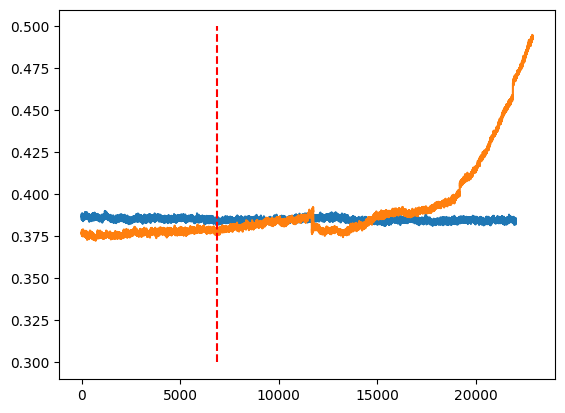

In [ ]:
asd = _load_mf4(file_path)
asd_2 = _load_mf4(
    file_path.parent.parent / "20221118_20290_20253_test2" / file_path.name
)

window = 99 * 200
asd = asd[int(0.3 * len(asd)) : int(0.9 * len(asd))]
asd = asd[: len(asd) - len(asd) % window].reshape((-1, window))

asd_2 = asd_2[int(0.3 * len(asd_2)) : int(0.8 * len(asd_2))]
asd_2 = asd_2[: len(asd_2) - len(asd_2) % window].reshape((-1, window))

plt.plot(np.sqrt(np.mean(np.pow(asd_2, 2), axis=1)))
plt.plot(np.sqrt(np.mean(np.pow(asd, 2), axis=1)))
plt.vlines(x=[0.3 * len(asd)], ymin=0.3, ymax=0.5, color="r", linestyle="--")

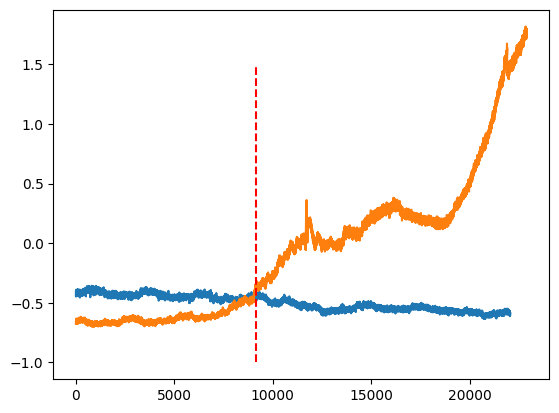

In [ ]:
plt.plot(kurtosis(asd_2, axis=1))
plt.plot(kurtosis(asd, axis=1))
plt.vlines(x=[0.4 * len(asd)], ymin=-1, ymax=1.5, color="r", linestyle="--")

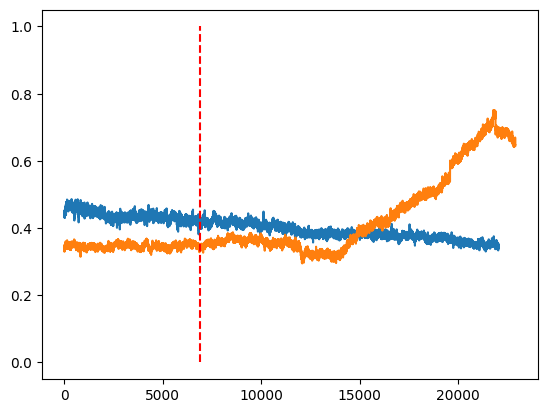

In [ ]:
plt.plot(skew(asd_2, axis=1))
plt.plot(skew(asd, axis=1))
plt.vlines(x=[0.3 * len(asd)], ymin=0, ymax=1, color="r", linestyle="--")

## OLD


In [ ]:
file_path = (
    # data_folder / "20221017_20252_20253_test4" / "Encoder.mf4"
    # data_folder / "20230317_20292_20253_test4" / "rotational_speed.mf4"
    data_folder
    / "20230317_20292_20253_test4"
    / "TC2_accelerometer_2_20253.mf4"
    # data_folder / "20230317_20292_20253_test4" / "TC2_torque_Pinion_20253.mf4"
)
signal = _load_mf4(file_path)  # [::100]

# plt.plot(signal)
# plt.vlines(
#     [0.20 * len(signal), 0.9 * len(signal)],
#     ymin=signal.min(),
#     ymax=signal.max(),
#     color="red",
#     linestyles="dashed",
# )

In [ ]:
len(signal) * 0.6 / 200 / 99

14436.235363636364

In [ ]:
data = pd.read_feather(Path.cwd().parent.parent / "data" / "TUNI_OT_20292.feather")
# data = data[data["run"] == "20230317_20292_20253_test4"]
data

,gear,position,run,num_consequtive,class,class_opposite,sample_index,acc1,acc2
0,20292,1,20230313_20292_20253_test1,4,healthy,faulty,0,"[0.00025816454, 0.000106803316, 0.0013464917, ...","[0.00014088582, 4.0212544e-05, 0.0005141213, 0..."
1,20292,1,20230313_20292_20253_test1,4,healthy,faulty,1,"[0.00024555495, 0.0001252154, 0.0013773735, 0....","[0.00028131256, 7.3507275e-05, 0.0006461256, 0..."
2,20292,1,20230313_20292_20253_test1,4,healthy,faulty,2,"[2.5207806e-05, 7.8634206e-05, 0.0012065283, 0...","[9.394402e-06, 3.0573414e-05, 0.00062466454, 0..."
3,20292,1,20230313_20292_20253_test1,4,healthy,faulty,3,"[0.00022632435, 9.561864e-05, 0.0013225203, 0....","[0.00018665135, 4.903503e-05, 0.00044129076, 0..."
4,20292,1,20230313_20292_20253_test1,4,healthy,faulty,4,"[0.00014897267, 0.00012264369, 0.0013748443, 0...","[0.00028848735, 0.000120800236, 0.00047880886,..."
...,...,...,...,...,...,...,...,...,...
20835,20292,1,20230505_20292_20291_test2,4,faulty,healthy,20835,"[0.00017677883, 7.450014e-05, 0.00093340536, 0...","[7.612778e-05, 6.381611e-05, 0.0004268772, 0.0..."
20836,20292,1,20230505_20292_20291_test2,4,faulty,healthy,20836,"[0.00048722807, 8.750753e-05, 0.0010028387, 0....","[0.0005284934, 5.7558264e-05, 0.0005604648, 0...."
20837,20292,1,20230505_20292_20291_test2,4,faulty,healthy,20837,"[0.00057714374, 7.949731e-05, 0.0009840162, 0....","[0.0002201561, 2.8223618e-05, 0.0005676927, 0...."
20838,20292,1,20230505_20292_20291_test2,4,faulty,healthy,20838,"[0.00021754562, 9.332188e-05, 0.0009192727, 0....","[0.00030918542, 7.5914184e-05, 0.0005633078, 0..."


In [ ]:
fig = go.Figure()

data_h = data[data["run"] == "20230313_20292_20253_test1"]

fig.add_trace(go.Scatter(y=data_h["acc1"].iloc[0], mode="lines", name="1"))
fig.add_trace(go.Scatter(y=data_h["acc1"].iloc[10000], mode="lines", name="10000"))
fig.add_trace(go.Scatter(y=data_h["acc1"].iloc[-1], mode="lines", name="-1"))

In [ ]:
fig = go.Figure()

data_2 = data[data["run"] == "20230315_20292_20253_test2"]

fig.add_trace(go.Scatter(y=data_2["acc1"].iloc[0], mode="lines", name="1"))
fig.add_trace(go.Scatter(y=data_2["acc1"].iloc[10000], mode="lines", name="10000"))
fig.add_trace(go.Scatter(y=data_2["acc1"].iloc[-1], mode="lines", name="-1"))

In [ ]:
fig = go.Figure()

data_3 = data[data["run"] == "20230505_20292_20291_test2"]

fig.add_trace(go.Scatter(y=data_3["acc1"].iloc[0], mode="lines", name="1"))
fig.add_trace(go.Scatter(y=data_3["acc1"].iloc[10000], mode="lines", name="10000"))
fig.add_trace(go.Scatter(y=data_3["acc1"].iloc[-1], mode="lines", name="-1"))

In [ ]:
# def keep_every_nth_true(bool_array, n=10):
#     """
#     Returns a new array where only every nth True value is kept and the rest are changed to False.

#     Parameters:
#     -----------
#     bool_array : numpy.ndarray
#         Input boolean array
#     n : int, optional
#         Keep every nth True value (default is 10)

#     Returns:
#     --------
#     numpy.ndarray
#         New boolean array with only every nth True value kept
#     """
#     # Convert to numpy array if it's not already
#     arr = np.array(bool_array, dtype=bool)

#     # Create a copy to modify
#     result = np.zeros_like(arr, dtype=bool)

#     # Find all True indices
#     true_indices = np.where(arr)[0]

#     # Keep only every nth index
#     indices_to_keep = true_indices[::n]

#     # Set those indices to True in the result
#     result[indices_to_keep] = True

#     return result


def order_track_signal(
    signal,
    time,
    angle,
    num_samples_per_revolution,
):
    """
    Resample a vibration signal from constant time intervals to constant shaft angle intervals.

    Parameters:
    -----------
    signal : numpy.ndarray
        The vibration signal sampled at constant time intervals.
    t : numpy.ndarray
        Timestamps corresponding to each sample in the signal.
    angle : numpy.ndarray
        Shaft angle (unwrapped) at each sample point.
    num_samples_per_revolution : int
        Number of sample points per revolution to include after resampling.
    fs : int
        Sampling frequency of the original signal.
    highest_rpm : int
        Highest RPM in the signal (required for anti-aliasing filter).
    num_teeth : int
        Number of teeth in gear being tracked.
    skip_anti_aliasing_warning : bool
        If True, skip raising an error if the sampling frequency isn't enough for 8 orders of GMF. Default is False.

    Returns:
    --------
    numpy.ndarray
        The resampled signal at constant shaft angle intervals.
    """

    # Constants
    encoder_target = 5  # * Arbitrarily chosen key revolution starting point

    # Wrap the encoder angle (degrees)
    encoder_wrapped = angle % 360

    # Validate inputs
    assert len(signal) == len(
        time
    ), f"Signal and timestamps must have the same length ({len(signal)} vs {len(time)})"
    assert len(signal) == len(
        angle
    ), f"Signal and angle must have the same length ({len(signal)} vs {len(angle)})"
    assert len(signal) > 0, "Signal must not be empty"

    # ORDER TRACKING
    ##

    # Get times of crossings
    crossings = np.where(
        np.logical_and(
            encoder_wrapped[:-1] <= encoder_target, encoder_wrapped[1:] > encoder_target
        )
    )[0]

    # Get accurate times for crossings
    t_crossings = time[crossings] + (encoder_target - encoder_wrapped[crossings]) / (
        encoder_wrapped[crossings + 1] - encoder_wrapped[crossings]
    ) * (time[crossings + 1] - time[crossings])

    # Create angles for each crossing (different anchor to original encoder angles)
    angle_crossings = np.arange(len(t_crossings)) * 360

    # Add intermediate sampling point angles
    interpolation_angles = (
        np.arange(num_samples_per_revolution * (len(t_crossings) - 1))
        / num_samples_per_revolution
        * 360
    )
    # Get corresponding times for each new sample point
    interpolation_times = np.interp(interpolation_angles, angle_crossings, t_crossings)

    cs = CubicSpline(time, signal)

    return cs(interpolation_times)

In [ ]:
tacho = np.array([0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0])

# If tacho has multiple non-zero values in a row, keep only the first one
keep_mask = (tacho == 1) & np.concatenate(([True], tacho[:-1] == 0))
filtered_tacho = np.zeros_like(tacho)
filtered_tacho[keep_mask] = 1
tacho = filtered_tacho

tacho

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0])

In [ ]:
# PROCESSING

# TSA
sampling_rate = 5000  # Hz
# sampling_rate_enc = 500  # Hz
revolutions_per_TSA = 99
step_size = 200
num_samples_per_revolution = 200
num_teeth = 9  # Pinion

# Specify raw data
data_folder = Path("/Volumes/T7-Aalto/TUNI-KONG_comb")
# files = data_folder.glob("**/*.mf4")

# Go through files
dfs = []
for PW in ["20252", "20253", "20254", "20289", "20290", "20291", "20292"]:
    for i, run in enumerate(runs_by_gear[PW]):
        # for PW in ["20290"]:
        #     for i, run in enumerate(runs_by_gear[PW][:3]):  # XXX
        print(f"> {run}")
        # SPECS
        ##

        status = run["status"]
        status_opposite = run["status_opposite"]
        position = run["position"]
        start, end = run["take"]

        # SIGNAL
        ##

        print(">>", run["folder"])
        signal_1 = _load_mf4(
            data_folder / run["folder"] / f"TC{position}_accelerometer_1_{PW}.mf4"
        )
        signal_2 = _load_mf4(
            data_folder / run["folder"] / f"TC{position}_accelerometer_2_{PW}.mf4"
        )  # XXX
        tacho = _load_mf4(data_folder / run["folder"] / f"Encoder.mf4")

        # ENCODER TO ANGLE

        assert signal.dtype == "int16", "Signal must be int16!"
        # Encoder signal seems to be pre-treated with only 0 and 1, but verify just in case
        if not np.all((tacho == 0) | (tacho == 1)):
            print(f"Encoder signal not binary (0 or 1)! ({np.unique_counts(tacho)})")
            tacho = tacho.astype(bool).astype(np.int16)  # Convert to [1, 0]

        # Assumes only one True value per peak
        assert all(
            tacho[1:] + tacho[:-1] < 1.5
        ), "Encoder signal has multiple True values per peak!"

        # Get rev start indices
        crossing_idxs = np.where(np.diff(tacho) == 1)[0]
        # Cumulative angle at rev start indices
        angle = np.arange(len(crossing_idxs)) * 360
        # Fill in the angle at every sample point
        # `* 10` because encoder sampling rate is 500 Hz and accelerometer is 5000 Hz
        interpolated_angle = np.interp(
            np.arange(len(tacho) * 10), crossing_idxs * 10, angle
        )
        # Cut to signal length
        # Slightly different lengths due to different sampling rates,
        # but close enough (especially taking into account very long measurement) that cutting to length shouldn't be a problem
        signal_1 = signal_1[200:-200]
        signal_2 = signal_2[200:-200]  # XXX
        interpolated_angle = interpolated_angle[200:]
        interpolated_angle = interpolated_angle[: len(signal_1)]

        # Verify everything looks good
        if len(interpolated_angle) != len(signal_1):
            raise ValueError(
                f"Angle & signal_1 lengths do not match ({len(interpolated_angle)} VS {len(signal_1)})!"
            )
        elif len(signal_1) != len(signal_2):  # XXX
            raise ValueError(
                f"Signal 1 & 2 lengths do not match ({len(signal_1)} VS {len(signal_2)})!"
            )

        # CUT

        # FIXME: MAYBE DO THIS AT START?
        # Runs generally contain unstable conditions at the beginning and end
        signal_1 = signal_1[int(start * len(signal_1)) : int(end * len(signal_1))]
        signal_2 = signal_2[int(start * len(signal_2)) : int(end * len(signal_2))]
        interpolated_angle = interpolated_angle[
            int(start * len(interpolated_angle)) : int(end * len(interpolated_angle))
        ]

        # PARTITION
        # Split into thirds, because otherwise order tracking crashes the kernel
        signal_1_parts = []
        signal_2_parts = []  # XXX
        interpolated_angle_parts = []

        # Signal 1
        signal_1_parts.append(signal_1[: int(0.33 * len(signal_1))])
        signal_1_parts.append(
            signal_1[int(0.33 * len(signal_1)) : int(0.66 * len(signal_1))]
        )
        signal_1_parts.append(signal_1[int(0.66 * len(signal_1)) :])

        # Signal 2 # XXX
        signal_2_parts.append(signal_2[: int(0.33 * len(signal_2))])
        signal_2_parts.append(
            signal_2[int(0.33 * len(signal_2)) : int(0.66 * len(signal_2))]
        )
        signal_2_parts.append(signal_2[int(0.66 * len(signal_2)) :])

        # Angle
        interpolated_angle_parts.append(
            interpolated_angle[: int(0.33 * len(interpolated_angle))]
        )
        interpolated_angle_parts.append(
            interpolated_angle[
                int(0.33 * len(interpolated_angle)) : int(
                    0.66 * len(interpolated_angle)
                )
            ]
        )
        interpolated_angle_parts.append(
            interpolated_angle[int(0.66 * len(interpolated_angle)) :]
        )

        # OT & TSA
        # Signal OT method
        all_signals_OT = []
        # for k, signal_parts in enumerate([signal_1_parts]): # YYY
        for k, signal_parts in enumerate([signal_1_parts, signal_2_parts]):  # XXX
            signal_samples_OT = []

            for j in range(len(signal_parts)):  # XXX
                # for j in range(1, 2):
                print(f"Signal {k + 1} part {j + 1}")

                # OT
                signal_OT = order_track_signal(
                    signal_parts[j],
                    np.arange(len(signal_parts[j])) / sampling_rate,
                    interpolated_angle_parts[j],
                    num_samples_per_revolution=num_samples_per_revolution,
                )

                # TSA # FIXME
                signal_OT_TSA = signal_TSA(
                    signal_OT,
                    num_samples_per_revolution,
                    revolutions_per_TSA,
                    step_size,
                )
                # FFT
                # Drop first few and last in case of interpolation artifacts
                # Keep 10 first full GMFs and the DC component
                samples = np.abs(np.fft.rfft(signal_OT_TSA, norm="forward", axis=1))[
                    2:-2,
                    :,
                    # 2:-2, : 11 * num_teeth
                ]

                samples = samples.astype(np.float32)
                signal_samples_OT.extend(samples)

            all_signals_OT.append(signal_samples_OT)

        # (num_signals, num_samples, sample_len)
        all_signals_OT = np.array(all_signals_OT)

        print("Shape of all_signals_OT:", all_signals_OT.shape)

        # Make a new row for the DF for every TSA sample
        expanded_rows = []
        sample_i = 0
        for j in range(all_signals_OT.shape[1]):
            expanded_rows.append(
                {
                    "test_run": i + 1,
                    "position": position,
                    "class": status,
                    "class_opposite": status_opposite,
                    # "OT_method": "signal",
                    # "TSA_size": revolutions_per_TSA,
                    "sample_index": sample_i,
                    "acc1": all_signals_OT[0][j],
                    "acc2": all_signals_OT[1][j],
                }
            )
            sample_i += 1

        # Make DF of one file
        dfs.append(pd.DataFrame(expanded_rows))

# Combine files
dfs = pd.concat(dfs)
dfs.head(3)

> {'folder': '20221014_20252_20253_test3', 'position': 1, 'status': 'healthy', 'status_opposite': 'healthy', 'take': [0.2, 0.7], 'speed': 1500}
>> 20221014_20252_20253_test3
Signal 1 part 1
Signal 1 part 2
Signal 1 part 3
Signal 2 part 1
Signal 2 part 2
Signal 2 part 3
Shape of all_signals_OT: (2, 10882, 101)
> {'folder': '20221017_20252_20253_test4', 'position': 1, 'status': 'healthy', 'status_opposite': 'healthy', 'take': [0.2, 0.8], 'speed': 1500}
>> 20221017_20252_20253_test4
Encoder signal not binary (0 or 1)! (UniqueCountsResult(values=array([0, 1, 2], dtype=int16), counts=array([69828044,  3535325,        1])))
Signal 1 part 1
Signal 1 part 2
Signal 1 part 3
Signal 2 part 1
Signal 2 part 2
Signal 2 part 3
Shape of all_signals_OT: (2, 10981, 101)
> {'folder': '20221021_20252_20253_test5', 'position': 1, 'status': 'maybe_faulty', 'status_opposite': 'healthy', 'take': [0.2, 0.75], 'speed': 1500}
>> 20221021_20252_20253_test5
Signal 1 part 1
Signal 1 part 2
Signal 1 part 3
Signal 2 

AssertionError: Encoder signal has multiple True values per peak!

In [ ]:
dfs.groupby(["test_run", "class"]).count()

In [ ]:
px.line(dfs["acc2"].iloc[-1])

In [ ]:
px.line(np.log10(dfs["acc2"].iloc[0]))

In [ ]:
data = pd.read_feather(Path.cwd().parent.parent / "data" / "TUNI_OT_20292.feather")

In [ ]:
px.line(data["acc1"].iloc[-1])

In [ ]:
data.shape

(17594, 7)

## TEST RUN


In [ ]:
file_path = ()
signal = _load_mf4(
    data_folder / "20221121_20290_20253_test3" / "TC1_accelerometer_1_20290.mf4"
)
encoder = _load_mf4(data_folder / "20221121_20290_20253_test3" / "Encoder.mf4")
speed = _load_mf4(data_folder / "20221121_20290_20253_test3" / "rotational_speed.mf4")
# print(len(speed)) # ! Where is this calculated from?
print(len(encoder))
print(len(signal))

print(np.unique_values(np.diff(np.where(encoder)[0])))

signal = signal[len(signal) // 3 : len(signal) // 3 + 5000 * 10]
encoder = encoder[len(encoder) // 3 : len(encoder) // 3 + 5000 * 10]
speed = speed[len(speed) // 3 : len(speed) // 3 + 5000 * 10]

plt.plot(signal)

In [ ]:
px.line(x=np.fft.rfftfreq(len(signal), d=1 / 5000), y=np.abs(np.fft.rfft(signal)))

In [ ]:
plt.plot(encoder[:500])
print(encoder > 0.8)
print(np.unique_values(np.diff(np.where(encoder[:500])[0])))
print(sum(encoder[:500]))

In [ ]:
crossing_idxs = np.where(np.diff(encoder) == 1)[0]

# # Cumulative angle at rev start indices
angle = np.arange(len(crossing_idxs)) * 360
# # Fill in the angle at every sample point
# # `* 10` because encoder sampling rate is 500 Hz and accelerometer is 5000 Hz
interpolated_angle = np.interp(
    np.arange(len(encoder) * 10),
    crossing_idxs * 10,
    angle,
    # np.arange(len(tacho) * 10), crossing_idxs * 10, angle
)
px.line(interpolated_angle[:600])

In [ ]:
signal = signal[200:]
interpolated_angle = interpolated_angle[200:]
interpolated_angle = interpolated_angle[: len(signal)]

print(interpolated_angle.shape)
print(signal.shape)

In [ ]:
signal_OT = order_track_signal(
    signal,
    np.arange(len(signal)) / 5000,
    interpolated_angle,
    num_samples_per_revolution=200,
)
fig = go.Figure()
fig.add_scatter(y=signal[4:1004], mode="lines", name="original")
fig.add_scatter(y=signal_OT[:1000], mode="lines", name="OT signal")

In [ ]:
fig = go.Figure()
fig.add_scatter(y=np.abs(np.fft.rfft(signal[4:5004])), mode="lines", name="original")
# fig.add_scatter(y=np.abs(np.fft.rfft(signal_OT[:5000])), mode="lines", name="OT signal")

In [ ]:
fig = go.Figure()
# fig.add_scatter(y=np.abs(np.fft.rfft(signal[4:5004])), mode="lines", name="original")
fig.add_scatter(y=np.abs(np.fft.rfft(signal_OT[:5000])), mode="lines", name="OT signal")

In [ ]:
fig = go.Figure()
fig.add_scatter(y=signal[:200], mode="lines", name="1")
fig.add_scatter(y=signal[200:400], mode="lines", name="2")
fig.add_scatter(y=signal[400:600], mode="lines", name="3")

In [ ]:
signal_TSA = signal.reshape(-1, 200).mean(axis=0)
signal_OT_TSA = signal_OT.reshape(-1, 200).mean(axis=0)

fig = go.Figure()
fig.add_scatter(y=np.abs(np.fft.rfft(signal_TSA)), mode="lines", name="original")
fig.add_scatter(y=np.abs(np.fft.rfft(signal_OT_TSA)), mode="lines", name="OT signal")

In [ ]:
asd = np.fft.rfft(signal.reshape(-1, 200))

asd_1 = np.abs(asd).mean(axis=0)
asd_1 /= np.max(asd_1)

asd_2 = np.abs(asd.mean(axis=0))
asd_2 /= np.max(asd_2)

fig = go.Figure()
fig.add_scatter(y=asd_1, mode="lines", name="original")
fig.add_scatter(y=asd_2, mode="lines", name="OT signal")

In [ ]:
asd_3 = np.abs(np.fft.rfft(signal_OT.reshape(-1, 200).mean(axis=0)))
asd_3 /= np.max(asd_3)

fig = go.Figure()
fig.add_scatter(y=asd_1, mode="lines", name="amplitude mean")
fig.add_scatter(y=asd_2, mode="lines", name="amplitude + phase mean")
fig.add_scatter(y=asd_3, mode="lines", name="OT signal (mean)")

## OTHER


In [ ]:
# file_path = data_folder / "20221116_20290_20253_test1" / "Encoder.mf4"  # 75323520
# signal_enc = _load_mf4(file_path)

# file_path = data_folder / "20221116_20290_20253_test1" / "rotational_speed.mf4"  # 75323520
# signal_speed = _load_mf4(file_path)

file_path = (
    data_folder / "20221116_20290_20253_test1" / "TC1_accelerometer_2_20290.mf4"
)  # healthy
signal_healthy = _load_mf4(file_path)
file_path = (
    data_folder / "20221121_20290_20253_test3" / "TC1_accelerometer_2_20290.mf4"
)  # faulty
signal_faulty = _load_mf4(file_path)

signal_cut_healthy = signal_healthy[
    int(0.5 * len(signal_healthy)) : int(0.5 * len(signal_healthy)) + 10 * 5000
]
plt.plot(signal_cut_healthy, alpha=0.5)
signal_cut_faulty = signal_faulty[
    int(0.5 * len(signal_faulty)) : int(0.5 * len(signal_faulty)) + 10 * 5000
]
plt.plot(signal_cut_faulty, alpha=0.5)
plt.show()

NameError: name 'data_folder' is not defined

In [ ]:
fft = np.fft.rfft(signal_cut_healthy)
freq = np.fft.rfftfreq(len(signal_cut_healthy), d=1 / 5000)

fig1 = px.line(
    x=freq[:10000],
    y=np.log(np.abs(fft))[:10000],
    labels={"x": "Frequency (Hz)", "y": "FFT Amplitude"},
).update_layout(
    title="FFT of healthy signal",
    xaxis_title="Frequency (Hz)",
    yaxis_title="FFT Amplitude",
    width=1200,
    height=400,
)
fig1.show()

fft = np.fft.rfft(signal_cut_faulty)
freq = np.fft.rfftfreq(len(signal_cut_faulty), d=1 / 5000)

fig2 = px.line(
    x=freq[:10000],
    y=np.log(np.abs(fft))[:10000],
    labels={"x": "Frequency (Hz)", "y": "FFT Amplitude"},
).update_layout(
    title="FFT of faulty signal",
    xaxis_title="Frequency (Hz)",
    yaxis_title="FFT Amplitude",
    width=1200,
    height=400,
)
fig2.show()

In [ ]:
# data_folder = Path.cwd().parent.parent.parent / "data" / "Kongsberg"
data_folder = Path("/Volumes/T7-Aalto/TUNI-KONG_comb")
# file_path = data_folder / "20220628_18990_20254_test1" / "rotational_speed.mf4"
# file_path = data_folder / "20220629_18990_20254_test2" / "TC2_torque_Wheel_20254.mf4"
# file_path = data_folder / "20220818_18990_20254_test3" / "TC2_torque_Wheel_20254.mf4"
# file_path = data_folder / "20220819_18990_20254_test4" / "TC2_torque_Wheel_20254.mf4"
# file_path = data_folder / "20220822_18990_20254_test5" / "TC2_torque_Wheel_20254.mf4"
# file_path = data_folder / "20230505_20292_20291_test2" / "TC1_torque_Wheel_20292.mf4"
# file_path = data_folder / "20230505_20292_20291_test2" / "rotational_speed.mf4"
file_path = data_folder / "20221116_20290_20253_test1" / "Encoder.mf4"  # 75323520
# file_path = data_folder / "20221116_20290_20253_test1" / "TC1_accelerometer_1_20290.mf4" # 753235200

signal = _load_mf4(file_path)
print(len(signal))
plt.plot(signal[30000000:30000010])
# plt.plot(signal[200000:201000])

75323520
753235200

692813667
69281367

692813667
69281367
692813670

In [ ]:
np.sum(signal[30000000:30000200])

In [ ]:
# data_folder = Path.cwd().parent.parent.parent / "data" / "Kongsberg"
data_folder = Path("/Volumes/T7-Aalto/TUNI-KONG_comb")
# file_path = data_folder / "20220628_18990_20254_test1" / "rotational_speed.mf4"
# file_path = data_folder / "20220629_18990_20254_test2" / "TC2_torque_Wheel_20254.mf4"
# file_path = data_folder / "20220818_18990_20254_test3" / "TC2_torque_Wheel_20254.mf4"
# file_path = data_folder / "20220819_18990_20254_test4" / "TC2_torque_Wheel_20254.mf4"
# file_path = data_folder / "20220822_18990_20254_test5" / "TC2_torque_Wheel_20254.mf4"
# file_path = data_folder / "20230505_20292_20291_test2" / "TC1_torque_Wheel_20292.mf4"
file_path = data_folder / "20221116_20290_20253_test1" / "rotational_speed.mf4"
# file_path = data_folder / "20230505_20292_20291_test2" / "Encoder.mf4"
# file_path = data_folder / "20230313_20292_20253_test1" / "TC1_accelerometer_1_20292.mf4"

signal = _load_mf4(file_path)
print(len(signal))
# plt.plot(signal[50000:55000])
plt.plot(signal)

In [ ]:
file_path = data_folder / "20221116_20290_20253_test1" / "Encoder.mf4"
signal = _load_mf4(file_path)
px.line(signal[500000:500500])

In [ ]:
file_path = data_folder / "20221116_20290_20253_test1" / "rotational_speed.mf4"
signal = _load_mf4(file_path)
px.line(signal[500000:500500])

In [ ]:
file_path = data_folder / "20221116_20290_20253_test1" / "TC1_accelerometer_2_20290.mf4"
signal = _load_mf4(file_path)
signal = signal[10000000:10050000]
fig = px.line(signal)

file_path = data_folder / "20221121_20290_20253_test3" / "TC1_accelerometer_2_20290.mf4"
signal_faulty = _load_mf4(file_path)
signal_faulty = signal_faulty[10000000:10050000]
fig.add_scatter(x=np.arange(len(signal_faulty)), y=signal_faulty, mode="lines")

In [ ]:
fig = px.line(signal[:200])
r = 11
fig.add_scatter(x=np.arange(200), y=signal[800:1000], mode="lines")

In [ ]:
fig = go.Figure()

fig.add_scatter(
    x=np.fft.rfftfreq(len(signal), 1 / 5000),
    y=np.abs(np.fft.rfft(signal)),
    mode="lines",
    opacity=0.7,
    name="Healthy",
)
fig.add_scatter(
    x=np.fft.rfftfreq(len(signal_faulty), 1 / 5000),
    y=np.abs(np.fft.rfft(signal_faulty)),
    mode="lines",
    opacity=0.7,
    name="Faulty",
)

In [ ]:
np.arange(12).reshape(-1, 3)  # .max(axis=0)

In [ ]:
fig = go.Figure()

signal_fft = np.abs(np.fft.rfft(signal))[1:]
signal_down = signal_fft[:].reshape(-1, 100).max(axis=1)

signal_faulty_fft = np.abs(np.fft.rfft(signal_faulty))[1:]
print(signal_faulty_fft.shape)
signal_faulty_down = signal_faulty_fft[:].reshape(-1, 100).max(axis=1)
print(signal_faulty_down.shape)
# signal_faulty_down = np.abs(np.fft.rfft(signal_faulty))[1:-4].reshape(3, -1).mean(axis=0)

fig.add_scatter(
    x=np.arange(len(signal_faulty_down)),
    y=signal_faulty_down - signal_down,
    mode="lines",
    opacity=0.7,
    name="Healthy",
)
# fig.add_scatter(x=np.arange(len(signal_down)), y=signal_down, mode="lines", opacity=0.7, name="Healthy")
# fig.add_scatter(x=np.arange(len(signal_faulty_down)), y=signal_faulty_down, mode="lines", opacity=0.7, name="Healthy")

In [ ]:
TSA = signal[: 99 * 200].reshape(-1, 200).mean(axis=0)
px.line(TSA)

In [ ]:
px.line(np.abs(np.fft.rfft(TSA, norm="forward", axis=0)))
# px.line(x=np.fft.rfftfreq(len(TSA), 1/5000), y=np.abs(np.fft.rfft(TSA, norm="forward", axis=0)))

In [ ]:
px.line(
    x=np.fft.rfftfreq(99 * 200, 1 / 5000),
    y=np.abs(np.fft.rfft(signal[500012 : 500012 + 99 * 200])),
)

In [ ]:
1e7